# Modélisation des Valeurs Résiduelles : Nexialog x MoSEF
**Objectif :** Prédire le prix de revente (valeur résiduelle) de véhicules Renault/Dacia/Nissan à la fin de leurs contrats de leasing, à partir de transactions historiques sur le marché allemand.


## Imports & Chargement des données

In [158]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Gradient Boosting
from xgboost import XGBRegressor
import lightgbm as lgb

# SHAP
import shap

# Config affichage
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Chemins
DATA_DIR         = Path('.')
USED_MARKET_PATH = DATA_DIR / 'used_market.xlsb'
PORTFOLIO_PATH   = DATA_DIR / 'portfolio.xlsx'
USED_MARKET_CSV  = DATA_DIR / 'used_market.csv'   # cache CSV pour relecture rapide
OUTPUT_CSV       = DATA_DIR / 'predictions.csv'

# Fonctions utilitaires
from src.utils_fonction import load_data

In [159]:
mkt, pf = load_data(
    used_market_path=USED_MARKET_PATH,
    portfolio_path=PORTFOLIO_PATH,
)

[used_market] Lecture cache CSV : used_market.csv
[used_market] 736,958 lignes x 22 colonnes
[portfolio]   1,951 lignes x 19 colonnes


In [160]:
# Used Market  
display(mkt.head(3))
print('\nColonnes :', list(mkt.columns))

,country_code,brand,MODEL,MARK / Generation,Phase (Facelift),RANGE TYPE,FUEL TYPE,Engine Power (HP),gearbox,BODY TYPE,MODEL SEGMENT,grouping,modelyear,productionYear,id_group,id,date de vente,mileage,age,prix de vente,prix catalogue d'origine,sample size
0,DE,DACIA,LOGAN,1,1,PC,PETROL,74,Manual,SEDAN,B,"LOGAN, Limousine, Doors=4, Super, 55kW, M, 200...",2005,2005,242,242,43115,75000,120,1113,6675,1
1,DE,DACIA,LOGAN,1,1,PC,PETROL,74,Manual,SEDAN,B,"LOGAN, Limousine, Doors=4, Super, 55kW, M, 200...",2005,2005,242,242,43174,30000,108,1476,7055,1
2,DE,DACIA,LOGAN,1,1,PC,PETROL,74,Manual,SEDAN,B,"LOGAN, Limousine, Doors=4, Super, 55kW, M, 200...",2005,2005,242,242,43174,75000,120,992,6449,1



Colonnes : ['country_code', 'brand', 'MODEL', 'MARK / Generation', 'Phase (Facelift)', 'RANGE TYPE', 'FUEL TYPE', 'Engine Power (HP)', 'gearbox', 'BODY TYPE', 'MODEL SEGMENT', 'grouping', 'modelyear', 'productionYear', 'id_group', 'id', 'date de vente', 'mileage', 'age', 'prix de vente', "prix catalogue d'origine", 'sample size']


In [161]:
# Portfolio 
display(pf.head(3))
print('\nColonnes :', list(pf.columns))

,id,country_name,produit financier,version_name,brand,model,production_year,fuel_type,range_type,contract_start_date,current_contract_planned_end_date,contract_start_year,contract_end_year,contract_duration,remaining_contract_duration,contract_mileage,initial_car_age,initial_mileage,prix catalogue d'origine
0,1,Germany,OPERATIONAL LEASE,ADVANCE L1 TCE 100 FAP,RENAULT,KANGOO,2021,PETROL,LCV,2022-04-26,2026-04-25,2022,2026,48,3,50042,0,0,19440.00
1,2,Germany,OPERATIONAL LEASE,BLACK EDITION TCE 140 EDC GPF,RENAULT,SCENIC,2020,PETROL,PC,2021-02-27,2026-02-26,2021,2026,60,1,50025,0,0,30000.00
2,3,Germany,OPERATIONAL LEASE,BUSINESS EDITION TCE 90 (MY21),RENAULT,CLIO,2021,PETROL,PC,2023-01-17,2026-01-16,2023,2026,36,0,30023,1,45,15924.37



Colonnes : ['id', 'country_name', 'produit financier', 'version_name', 'brand', 'model', 'production_year', 'fuel_type', 'range_type', 'contract_start_date', 'current_contract_planned_end_date', 'contract_start_year', 'contract_end_year', 'contract_duration', 'remaining_contract_duration', 'contract_mileage', 'initial_car_age', 'initial_mileage', "prix catalogue d'origine"]


In [162]:
# Renommage et Nettoyage du Used Market

from src.utils_fonction import clean_used_market

mkt = clean_used_market(mkt)

Lignes supprimées (sale_price NaN) : 0
used_market après nettoyage : (736958, 22)


,country_code,brand,model,MARK / Generation,Phase (Facelift),range_type,fuel_type,Engine Power (HP),gearbox,body_type,model_segment,grouping,model_year,production_year,id_group,id,sale_date,mileage,age_months,sale_price,list_price,sample size
dtype,str,str,str,int64,int64,str,str,int64,str,str,str,str,int64,int64,int64,int64,datetime64[s],int64,int64,int64,int64,int64


In [163]:
# Renommage et Nettoyage du Portfolio
from src.utils_fonction import clean_portfolio

pf = clean_portfolio(pf)

portfolio après nettoyage : (1951, 19)


,id,country_name,produit financier,version_name,brand,model,production_year,fuel_type,range_type,contract_start_date,end_date,contract_start_year,contract_end_year,contract_duration,remaining_duration,contract_mileage,initial_age,initial_mileage,list_price
dtype,int64,str,str,str,str,str,int64,str,str,datetime64[us],datetime64[us],int64,int64,int64,int64,int64,int64,int64,float64


##  Analyse Exploratoire (EDA)
#### 2.1 Statistiques descriptives de la variable cible 

=== Statistiques sale_price (prix de vente) ===


,count,mean,std,min,25%,50%,75%,max
sale_price,736958.00,10293.85,6157.33,362.00,5939.00,9063.00,13192.00,117236.00


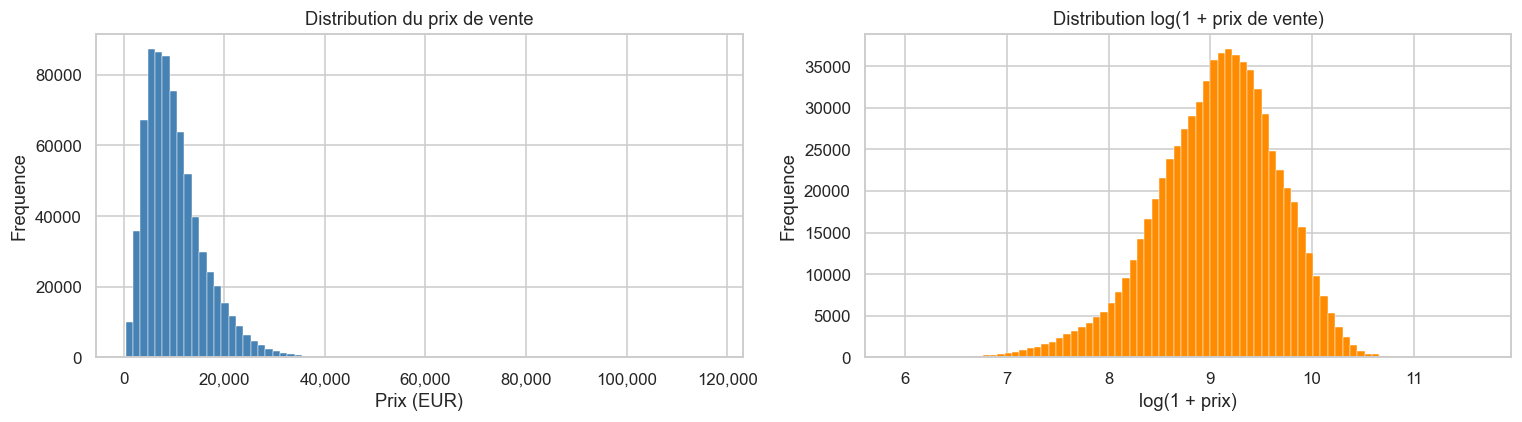

In [164]:
print('=== Statistiques sale_price (prix de vente) ===')
display(mkt['sale_price'].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(mkt['sale_price'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribution du prix de vente')
axes[0].set_xlabel('Prix (EUR)')
axes[0].set_ylabel('Frequence')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(np.log1p(mkt['sale_price']), bins=80, color='darkorange', edgecolor='white', linewidth=0.3)
axes[1].set_title('Distribution log(1 + prix de vente)')
axes[1].set_xlabel('log(1 + prix)')
axes[1].set_ylabel('Frequence')

plt.tight_layout()
plt.show()

**Distribution brute (gauche)**

La distribution est fortement asymétrique à droite : la majorité des
transactions se concentre entre 2 000 et 15 000 €, avec un pic autour de
5 000-8 000 €, puis une longue queue vers les prix élevés jusqu'à 120 000 €.
Cette asymétrie est classique sur les données de prix et cela risque de pénaliser les modèles
linéaires qui supposent une distribution symétrique des résidus.

**Distribution log-transformée (droite)**

Après transformation log(1 + prix), la distribution devient quasi-symétrique
et proche d'une gaussienne, centrée autour de 9 (soit e^9 ~ 8 100 €). C'est
une très bonne nouvelle pour la modélisation.

#### 2.2 Repartition par marque, carburant, segment 

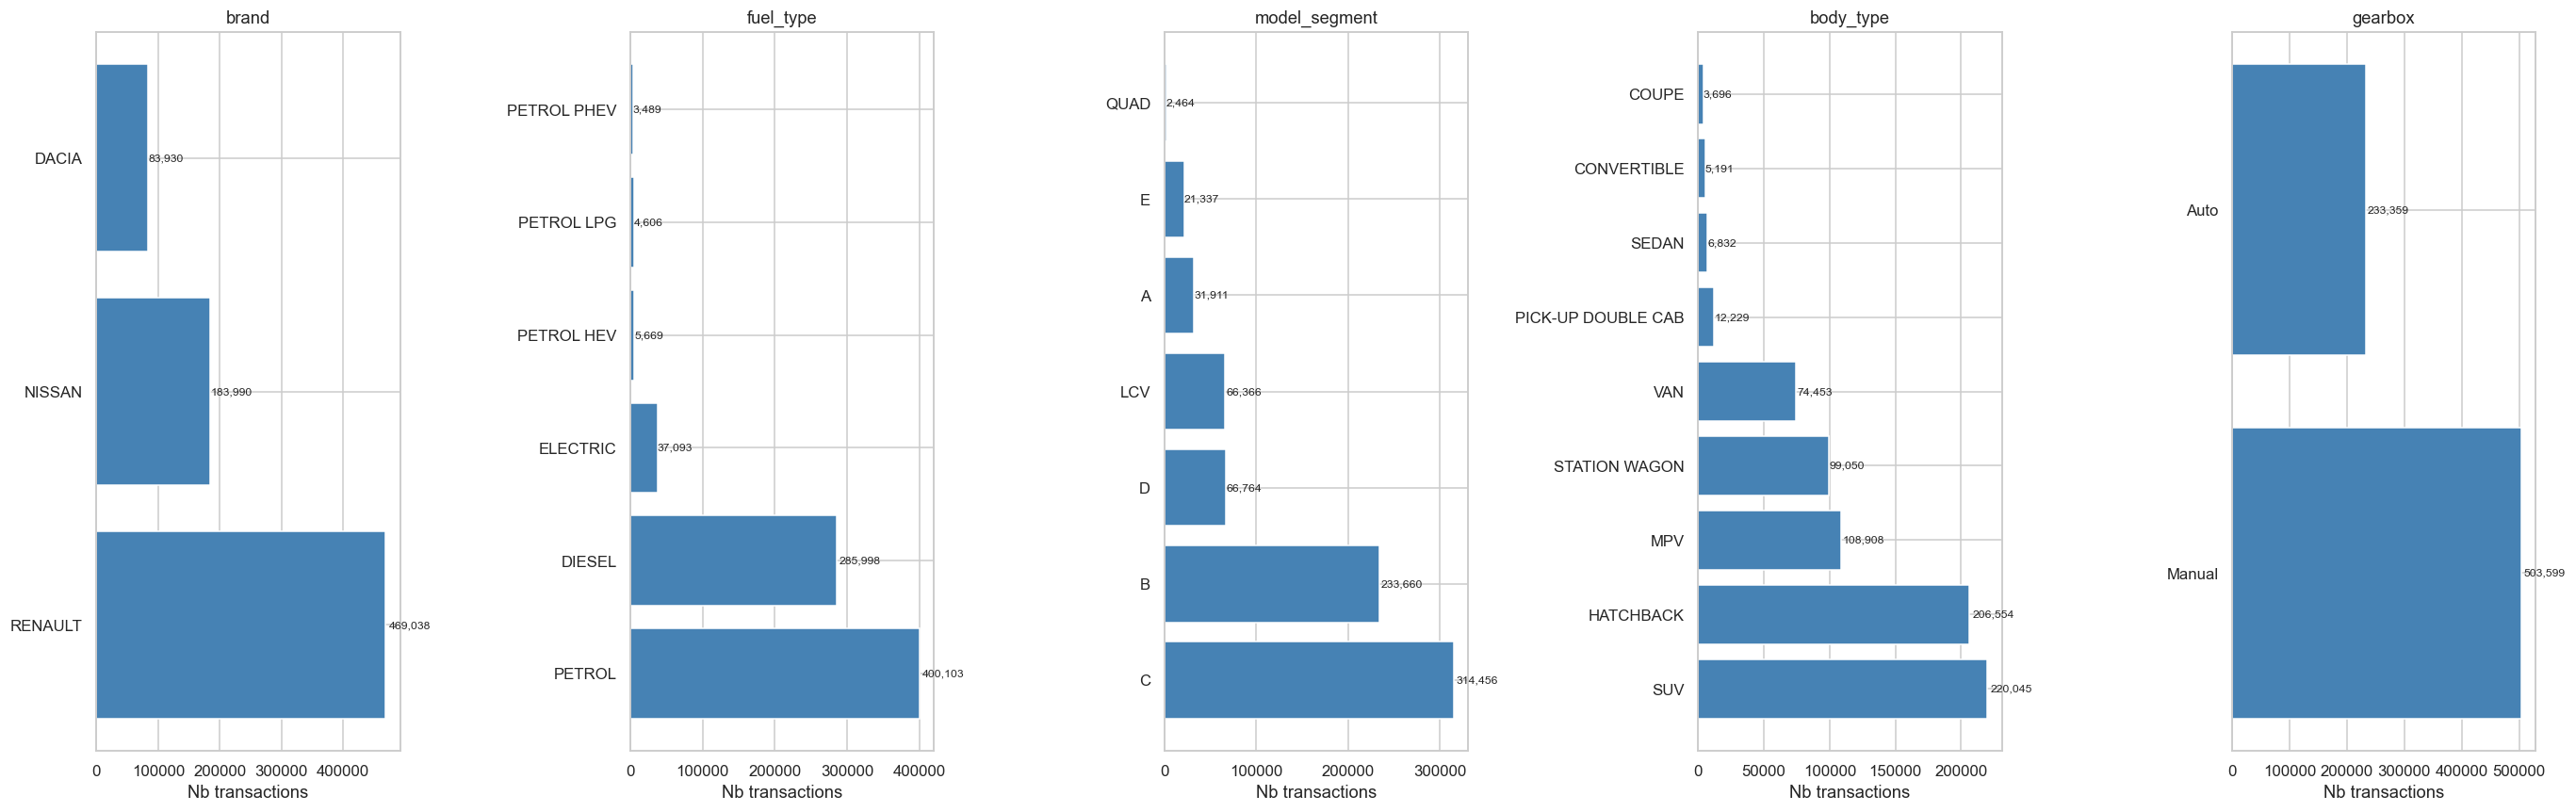

In [165]:
cat_cols = [c for c in ['brand', 'fuel_type', 'model_segment', 'body_type', 'gearbox'] if c in mkt.columns]
n = len(cat_cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 8))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    counts = mkt[col].value_counts()
    ax.barh(counts.index, counts.values, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('Nb transactions')
    for i, v in enumerate(counts.values):
        ax.text(v * 1.01, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

**Marque (brand)**

Renault domine largement avec 469 038 transactions, soit environ 64% du dataset.
Nissan représente 184 000 transactions et Dacia 84 000. Ce déséquilibre est
important : le modèle sera naturellement mieux calibré sur Renault que sur
les deux autres marques.

**Type de carburant (fuel_type)**

Petrol (400k) et Diesel (286k) représentent ensemble plus de 90% des transactions.
Les motorisations alternatives (Electric, HEV, PHEV, LPG) sont très minoritaires
avec moins de 40 000 observations chacune. La faible représentation de l'électrique
(37 093) est une limite directe pour prédire les véhicules électriques du portfolio.

**Segment (model_segment)**

Le segment C domine (314k), suivi du segment B (234k). Les segments premium
(E, QUAD) et les utilitaires (LCV) sont bien moins représentés. Le segment D
et LCV ont des volumes comparables autour de 66 000 transactions.

**Carrosserie (body_type)**

SUV (220k) et Hatchback (207k) sont les plus représentés, ce qui reflète
l'évolution du marché automobile européen vers les SUV ces dernières années.
MPV, Station Wagon et VAN complètent le tableau. Les Coupés et Cabriolets
sont anecdotiques dans ce dataset orienté marques généralistes.

**Boîte de vitesses (gearbox)**

La boîte manuelle domine nettement (504k vs 233k pour l'automatique), ce qui
est cohérent avec le marché allemand de l'occasion sur la période 2018-2025,
bien que la tendance soit à la progression de l'automatique sur les années
récentes.

####  2.3 Courbes de depreciation par type de carburant: prix median par tranche d'age 

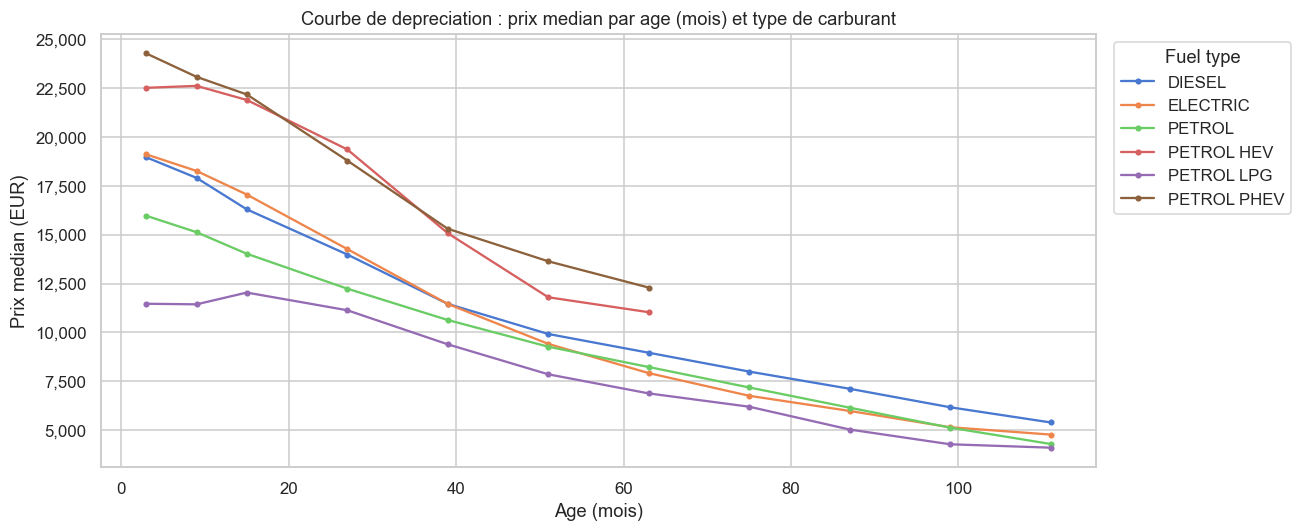

In [166]:
q_low  = mkt['sale_price'].quantile(0.01)
q_high = mkt['sale_price'].quantile(0.99)
mkt_viz = mkt[(mkt['sale_price'] >= q_low) & (mkt['sale_price'] <= q_high)].copy()

if 'age_months' in mkt_viz.columns and 'fuel_type' in mkt_viz.columns:
    mkt_viz['age_bin'] = pd.cut(mkt_viz['age_months'], bins=range(0, 120, 6), right=False)
    dep = (
        mkt_viz.groupby(['age_bin', 'fuel_type'], observed=True)['sale_price']
        .median()
        .reset_index()
    )
    dep['age_mid'] = dep['age_bin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)

    fig, ax = plt.subplots(figsize=(12, 5))
    for ft, grp in dep.groupby('fuel_type'):
        ax.plot(grp['age_mid'], grp['sale_price'], marker='o', markersize=3, label=ft)
    ax.set_title('Courbe de depreciation : prix median par age (mois) et type de carburant')
    ax.set_xlabel('Age (mois)')
    ax.set_ylabel('Prix median (EUR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title='Fuel type', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

**PETROL PHEV** démarre le plus haut (~24 000 €) et se déprécie très rapidement
jusqu'à 40 mois, signe d'un prix catalogue élevé et d'une forte décote initiale
liée à l'évolution rapide de la technologie hybride rechargeable.

**PETROL HEV** suit une trajectoire similaire mais part de ~22 500 € et se stabilise
davantage après 60 mois, ce qui suggère une meilleure rétention de valeur à long
terme que le PHEV.

**DIESEL** et **ELECTRIC** partent de niveaux proches (~19 000 €) mais divergent
progressivement : l'électrique conserve légèrement mieux sa valeur jusqu'à 60 mois,
avant de rejoindre le diesel autour de 8 000 € à 100 mois. Ce résultat est à
interpréter avec prudence car les données électriques sont moins denses sur les
véhicules âgés (peu de recul historique).

**PETROL** affiche la dépréciation la plus régulière et prévisible, ce qui en fait
une bonne référence pour la modélisation.

**PETROL LPG** présente un comportement atypique entre 0 et 20 mois (courbe plate
voire légèrement croissante), probablement dû à un faible volume de transactions
sur les véhicules jeunes — à surveiller lors du feature engineering.

> **Point d'attention** : les courbes ne sont pas linéaires.
> Une régression Ridge/Lasso devra intégrer `age_months²` ou une transformation
> log du prix pour capturer la convexité. XGBoost/LightGBM la capturera
> naturellement.

#### 2.4 Courbes de depreciation par marque 

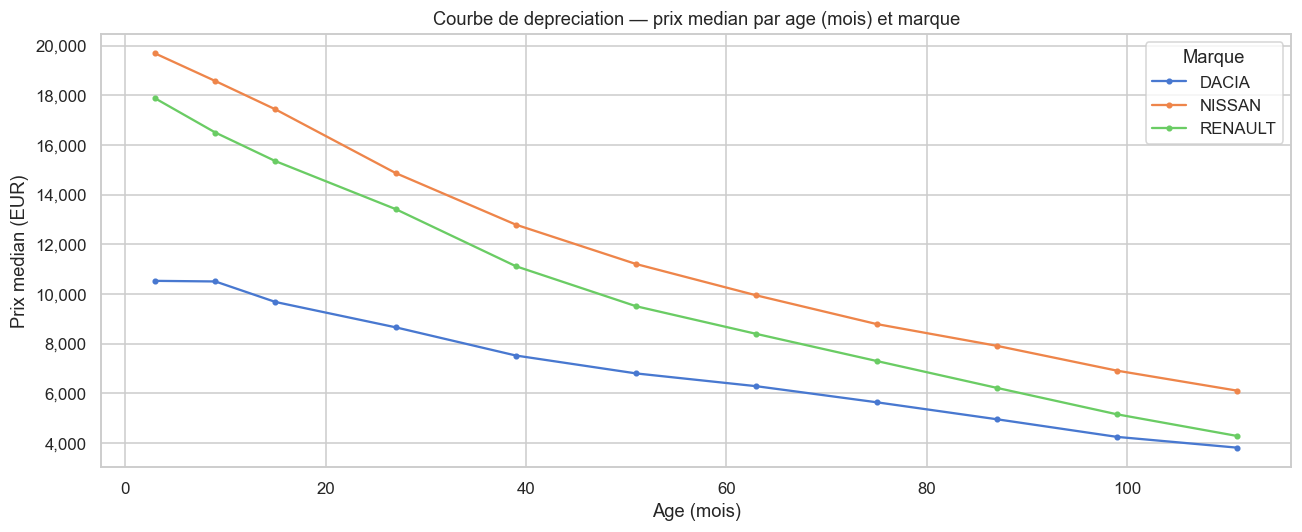

In [167]:
if 'age_months' in mkt_viz.columns and 'brand' in mkt_viz.columns:
    dep_brand = (
        mkt_viz.groupby(['age_bin', 'brand'], observed=True)['sale_price']
        .median()
        .reset_index()
    )
    dep_brand['age_mid'] = dep_brand['age_bin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)

    fig, ax = plt.subplots(figsize=(12, 5))
    for brand, grp in dep_brand.groupby('brand'):
        ax.plot(grp['age_mid'], grp['sale_price'], marker='o', markersize=3, label=brand)
    ax.set_title('Courbe de depreciation — prix median par age (mois) et marque')
    ax.set_xlabel('Age (mois)')
    ax.set_ylabel('Prix median (EUR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title='Marque')
    plt.tight_layout()
    plt.show()

Les trois marques suivent une dépréciation régulière et quasi-linéaire sur
l'ensemble de la période, ce qui est une bonne nouvelle pour la modélisation.

**Nissan** part le plus haut (~20 000 €) et maintient l'écart avec les deux
autres marques tout au long de la vie du véhicule. Sa courbe reste au-dessus
même à 110 mois (~6 000 €), signe d'un meilleur maintien de valeur absolu.

**Renault** démarre à ~18 000 € et se déprécie de façon très parallèle à Nissan,
avec un écart quasi-constant d'environ 2 000 € sur toute la durée. Les deux
marques ont des profils de dépréciation structurellement similaires.

**Dacia** se distingue nettement : prix de départ bien plus bas (~10 500 €) et
courbe plus plate en valeur absolue. Elle perd moins d'euros mais proportionnellement
la dépréciation reste forte. C'est cohérent avec son positionnement entrée de gamme, les acheteurs d'occasion valorisent moins ces véhicules.

> **Point d'attention** : la marque est clairement un déterminant
> fort du prix. Elle devra être encodée comme feature catégorielle (one-hot ou
> target encoding). L'écart Dacia vs Nissan/Renault suggère aussi qu'un modèle
> entraîné toutes marques confondues devra bien capturer cet effet — à vérifier
> via les SHAP values.

#### 2.5 Correlations numeriques avec sale_price 

Correlation avec sale_price :


,sale_price
sale_price,1.00
list_price,0.79
Engine Power (HP),0.68
model_year,0.62
production_year,0.62
Phase (Facelift),0.19
sample size,0.14
id_group,0.13
id,0.13
MARK / Generation,0.08


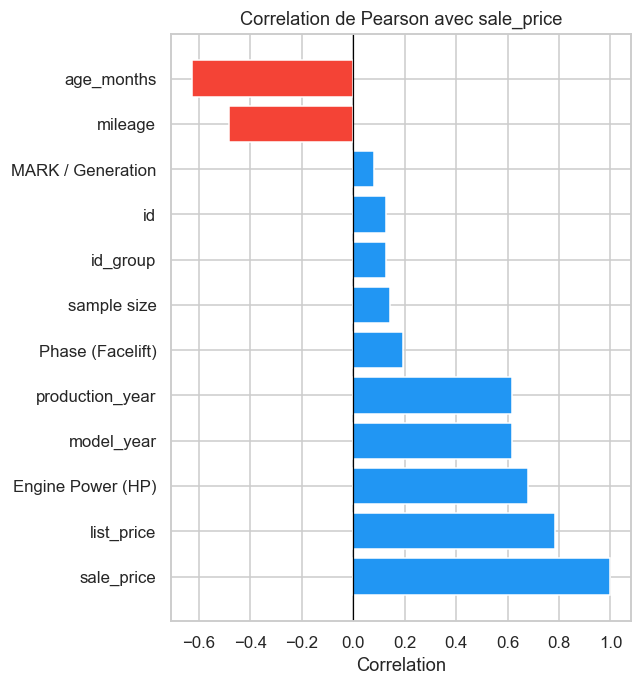

In [168]:
num_cols = mkt.select_dtypes(include='number').columns.tolist()
print('Correlation avec sale_price :')
corr = mkt[num_cols].corr()[['sale_price']].sort_values('sale_price', ascending=False)
display(corr)

fig, ax = plt.subplots(figsize=(6, len(num_cols) * 0.45 + 1))
colors = ['#2196F3' if v >= 0 else '#F44336' for v in corr['sale_price']]
ax.barh(corr.index, corr['sale_price'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation de Pearson avec sale_price')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

**Corrélations positives (le prix monte avec la variable)**

`list_price` (0.79) est la corrélation la plus forte, logique, le prix neuf
d'un véhicule conditionne fortement sa valeur de revente. Ce sera probablement
la feature la plus importante dans les modèles.

`Engine Power (0.68)`  plus le moteur est puissant, plus le véhicule se revend
cher. Capte indirectement le segment du véhicule (citadine vs SUV).

`model_year` et `production_year` (0.62 tous les deux), les véhicules récents
valent plus cher, ce qui est cohérent. Ces deux variables sont très corrélées
entre elles, attention à la **multicolinéarité** pour le modèle.

**Corrélations négatives (le prix baisse avec la variable)**

`age_months` (-0.63) plus le véhicule est vieux, moins il vaut. C'est le
moteur principal de la dépréciation, confirmé visuellement par les courbes 2.3
et 2.4.

`mileage` (-0.48) le kilométrage dégrade aussi la valeur, mais moins que l'âge
seul. Les deux sont liés (un vieux véhicule a généralement plus de km), à
surveiller via une matrice de corrélation complète.

**Variables à faible signal**

`Phase (Facelift)` (0.19), `id_group` (0.13), `id` (0.13) et `MARK / Generation`
(0.08) ont une corrélation très faible avec le prix. `id` et `id_group` sont des
identifiants techniques sans pouvoir prédictif réel **à exclure des features**.

> **Conclusion modélisation** : les 4 features numériques clés sont `list_price`,
> `engine_power`, `age_months` et `mileage`. Les variables catégorielles
> (marque, carburant, segment) non présentes ici viendront compléter ce signal
> une fois encodées.

#### 2.6 Scatter : age vs prix, colore par fuel_type 

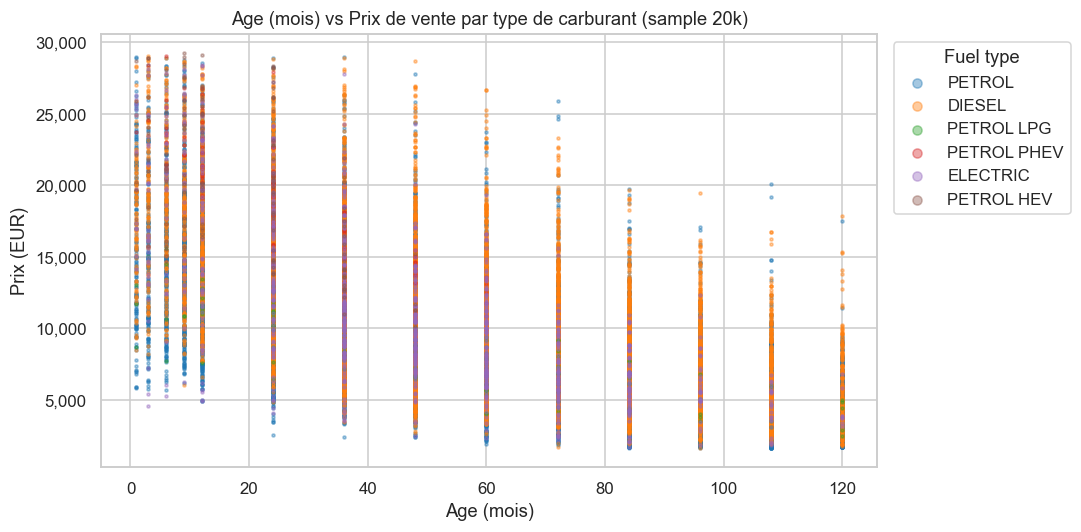

In [169]:
if 'age_months' in mkt_viz.columns:
    sample = mkt_viz.sample(min(20_000, len(mkt_viz)), random_state=42)
    fuels = sample['fuel_type'].unique() if 'fuel_type' in sample.columns else []
    palette = sns.color_palette('tab10', len(fuels))
    color_map = dict(zip(fuels, palette))

    fig, ax = plt.subplots(figsize=(10, 5))
    for ft in fuels:
        sub = sample[sample['fuel_type'] == ft]
        ax.scatter(sub['age_months'], sub['sale_price'],
                   s=4, alpha=0.4, color=color_map[ft], label=ft)
    ax.set_title('Age (mois) vs Prix de vente par type de carburant (sample 20k)')
    ax.set_xlabel('Age (mois)')
    ax.set_ylabel('Prix (EUR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title='Fuel type', markerscale=3, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Le premier constat frappant est la structure en colonnes verticales : les points
se regroupent sur des valeurs d'âge discrètes (0, 6, 12, 24, 36...) plutôt que
de se répartir continûment. Cela reflète la façon dont les données sont
collectées ou agrégées dans used_market, par tranches mensuelles fixes.

La dispersion verticale des prix est très large pour les véhicules jeunes
(0-12 mois) et se resserre progressivement avec l'âge. A 120 mois, tous les
carburants convergent vers une fourchette étroite autour de 2 000-10 000 €,
ce qui est cohérent avec les courbes de dépréciation vues en 2.3.

Les PETROL PHEV et PETROL HEV (rose/marron) sont quasi absents au-delà de
60 mois, ce qui confirme le manque de recul historique sur ces motorisations
récentes. Le modèle devra extrapoler pour ces carburants sur les contrats
longs du portfolio.

L'électrique (violet) reste peu représenté sur l'ensemble du graphe, surtout
après 40 mois. C'est une limite importante puisque le portfolio contient des
véhicules électriques avec des fins de contrat futures.

> **Point d'attention** : la structure discrète de l'axe âge
> suggère que `age_months` est une variable agrégée. Est ce que
> cette granularité est suffisante ou elle introduit un biais dans les
> prédictions pour les véhicules du portfolio qui auront des âges continus.

#### 2.7 Scatter : kilometrage vs prix 

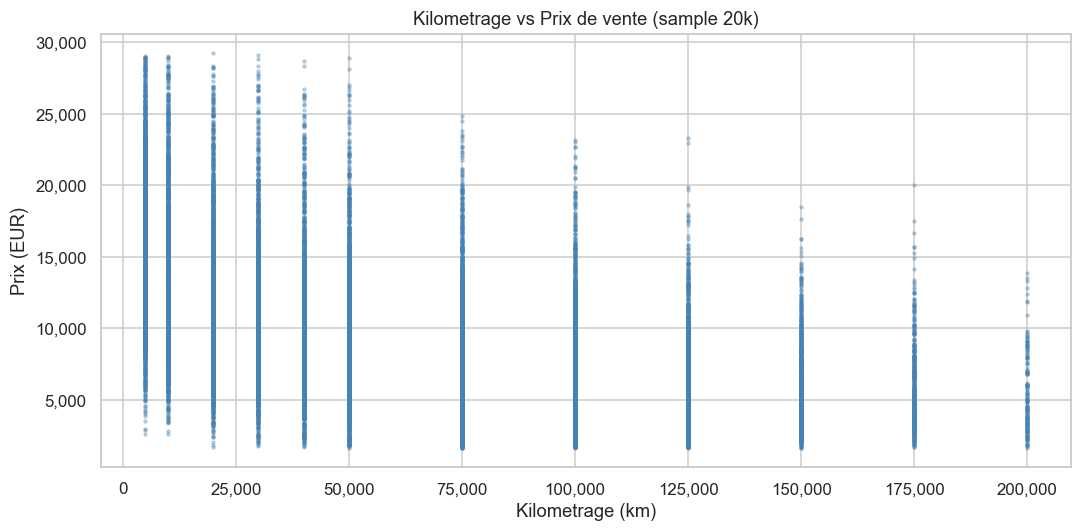

In [170]:
if 'mileage' in mkt_viz.columns:
    sample = mkt_viz.sample(min(20_000, len(mkt_viz)), random_state=42)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(sample['mileage'], sample['sale_price'],
               s=4, alpha=0.3, color='steelblue')
    ax.set_title('Kilometrage vs Prix de vente (sample 20k)')
    ax.set_xlabel('Kilometrage (km)')
    ax.set_ylabel('Prix (EUR)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

Même structure en colonnes verticales que le scatter précédent : le kilométrage
est lui aussi une variable discrète agrégée par paliers fixes (5 000, 10 000,
25 000, 50 000 km...). C'est une caractéristique des données used_market, pas
un artefact du code.

La tendance générale est claire : plus le kilométrage augmente, plus le prix
baisse et plus la dispersion se réduit. A 200 000 km, les prix convergent vers
une fourchette étroite de 2 000 à 10 000 €.

La densité de points est très concentrée sur les faibles kilométrages (0-50 000
km), ce qui reflète la composition du marché de l'occasion allemand : beaucoup
de véhicules jeunes et peu roulés.

Chose intéressante : pour un même kilométrage, la dispersion verticale reste
large, surtout sur les colonnes de gauche. Cela confirme que le kilométrage
seul ne suffit pas à expliquer le prix et qu'il interagit fortement avec l'âge,
la marque et le type de motorisation.

> **Point de vigilance modélisation** : kilométrage et âge sont corrélés entre
> eux mais apportent chacun un signal indépendant. Garder les deux en feature
> est justifié. Une feature dérivée comme le ratio `mileage / age_months`
> (intensité d'usage) pourrait capturer une information supplémentaire.

#### 2.8 Prix de vente par marque (boxplot) 

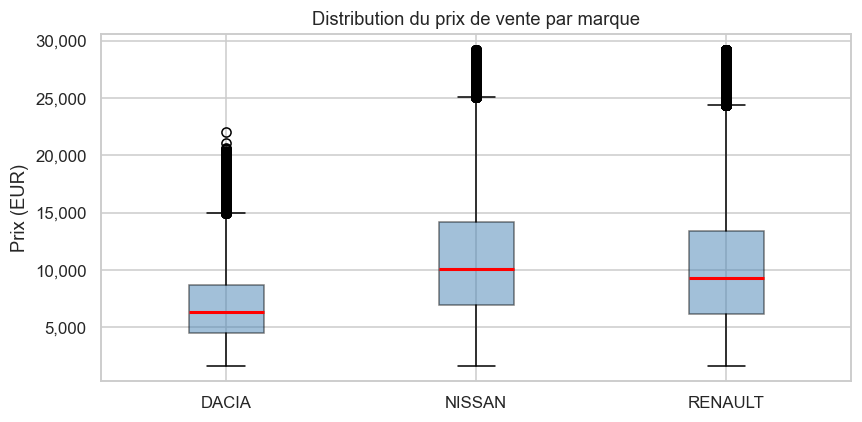

In [171]:
if 'brand' in mkt_viz.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    brands = mkt_viz['brand'].unique()
    data_box = [mkt_viz[mkt_viz['brand'] == b]['sale_price'].dropna().values for b in brands]
    ax.boxplot(data_box, labels=brands, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title('Distribution du prix de vente par marque')
    ax.set_ylabel('Prix (EUR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

Dacia se distingue nettement des deux autres avec une médiane autour de 6 000 €
et une boîte très resserrée (Q1~5 000 €, Q3~8 000 €). La distribution est
compacte, ce qui reflète un catalogue peu diversifié et des prix homogènes.
Les quelques points au-dessus de 15 000 € sont des outliers isolés.

Nissan et Renault ont des profils très proches : médiane autour de 10 000 €,
boîtes larges qui s'étendent de ~7 000 € à ~14 000 €. Cette variance plus
élevée s'explique par des gammes plus larges couvrant des segments différents
(citadines, SUV, utilitaires).

Nissan présente une moustache supérieure légèrement plus haute que Renault
(jusqu'à ~28 000 €), ce qui est cohérent avec des modèles premium comme le
Nissan Qashqai ou le X-Trail qui tirent la distribution vers le haut.

> **Remarque** : la marque agit comme un proxy du
> segment et du prix catalogue. Elle sera une feature importante mais attention
> au fait que Dacia, Nissan et Renault ne sont pas représentés de la meme facon dans
> le dataset, ce qui peut introduire un biais si le portfolio a une composition
> différente.

In [172]:
# Dates ventes 

print(mkt['sale_date'].head())

print(f"\n===={mkt['sale_date'].tail()}")

0   2018-01-15
1   2018-03-15
2   2018-03-15
3   2018-04-15
4   2018-04-15
Name: sale_date, dtype: datetime64[s]

====736953   2025-10-15
736954   2025-10-15
736955   2025-10-15
736956   2025-11-15
736957   2025-11-15
Name: sale_date, dtype: datetime64[s]


#### 2.9 Evolution temporelle du volume et du prix median 

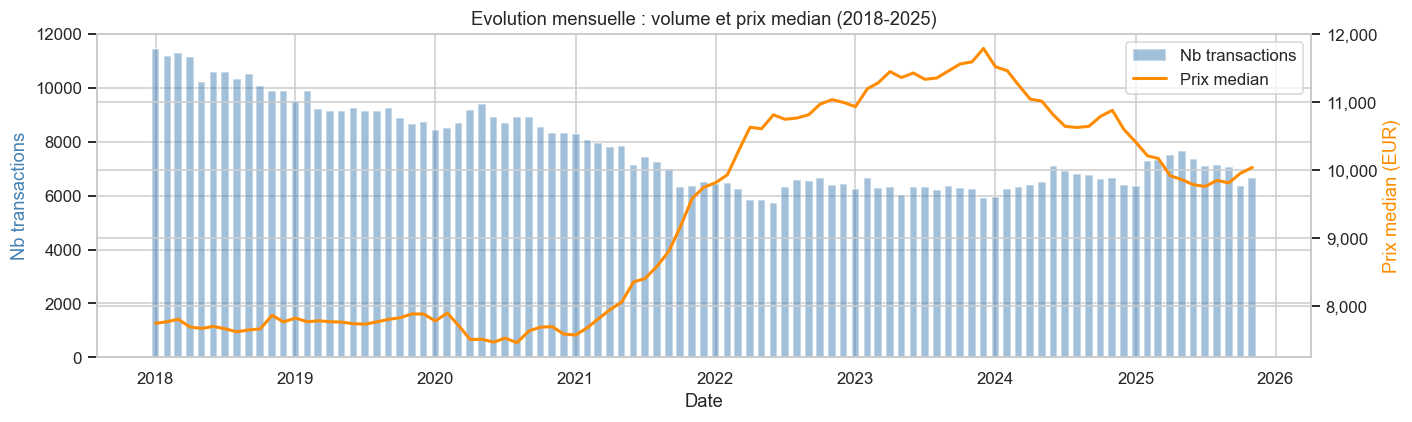

In [173]:
if 'sale_date' in mkt.columns:
    mkt_time = mkt.dropna(subset=['sale_date']).copy()
    mkt_time['year_month'] = mkt_time['sale_date'].dt.to_period('M')
    ts = mkt_time.groupby('year_month').agg(
        nb_transactions=('sale_price', 'count'),
        median_price=('sale_price', 'median')
    ).reset_index()
    ts['year_month_dt'] = ts['year_month'].dt.to_timestamp()

    fig, ax1 = plt.subplots(figsize=(13, 4))
    ax2 = ax1.twinx()
    ax1.bar(ts['year_month_dt'], ts['nb_transactions'], width=20,
            color='steelblue', alpha=0.5, label='Nb transactions')
    ax2.plot(ts['year_month_dt'], ts['median_price'],
             color='darkorange', linewidth=2, label='Prix median')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Nb transactions', color='steelblue')
    ax2.set_ylabel('Prix median (EUR)', color='darkorange')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax1.set_title('Evolution mensuelle : volume et prix median (2018-2025)')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    plt.tight_layout()
    plt.show()

**Volume de transactions (barres bleues)**

Le volume est stable et élevé sur 2018-2019 (~9 000-10 000 transactions/mois),
puis chute nettement début 2020 avec le Covid. Il remonte progressivement mais
ne retrouve jamais son niveau d'avant-crise, se stabilisant autour de 6 000-7 000
transactions/mois à partir de 2022. Cela semble contre - intuitif et peut venir d'une disproportion du dataset.

**Prix médian (courbe orange)**

C'est la tendance la plus remarquable du graphe. Le prix médian reste stable
autour de 7 500-8 000 € de 2018 à mi-2021, puis s'envole brutalement pour
atteindre un pic à ~12 000 € début 2024, soit une hausse de +50% en 3 ans.
Ce phénomène est directement lié à la pénurie de semi-conducteurs post-Covid
qui a réduit la production de véhicules neufs, reportant la demande sur
l'occasion et faisant monter les prix.

Depuis mi-2024, les prix amorcent une correction et redescendent vers 10 000 €
fin 2025, signalant une normalisation progressive du marché.

> **Point d'attention** : cette dynamique temporelle forte
> signifie que la date de vente est une feature importante. Un modèle entraîné
> sur 2018-2021 sous-estimerait systématiquement les prix de 2022-2024.
> Pour les prédictions du portfolio (fins de contrat futures), il faudra
> intégrer ou neutraliser cet effet prix de marché,
> qui est conjoncturel et difficile à extrapoler.

#### 2.10 Resume des valeurs manquantes 

In [174]:
print('=== used_market — Valeurs manquantes ===')
missing_mkt = mkt.isnull().sum().sort_values(ascending=False)
display(missing_mkt[missing_mkt > 0].to_frame('nb_NaN').assign(pct=lambda d: (d['nb_NaN'] / len(mkt) * 100).round(2)))

print('\n=== portfolio — Valeurs manquantes ===')
missing_pf = pf.isnull().sum().sort_values(ascending=False)
display(missing_pf[missing_pf > 0].to_frame('nb_NaN').assign(pct=lambda d: (d['nb_NaN'] / len(pf) * 100).round(2)))

=== used_market — Valeurs manquantes ===


,nb_NaN,pct



=== portfolio — Valeurs manquantes ===


,nb_NaN,pct


Pas de valeurs manquantes ce qui est une bonne nouvelle.

#### 2.11 Portfolio : dates de fin de contrat

Plage des dates de fin de contrat :
  Min : 2025-04-21
  Max : 2030-08-27


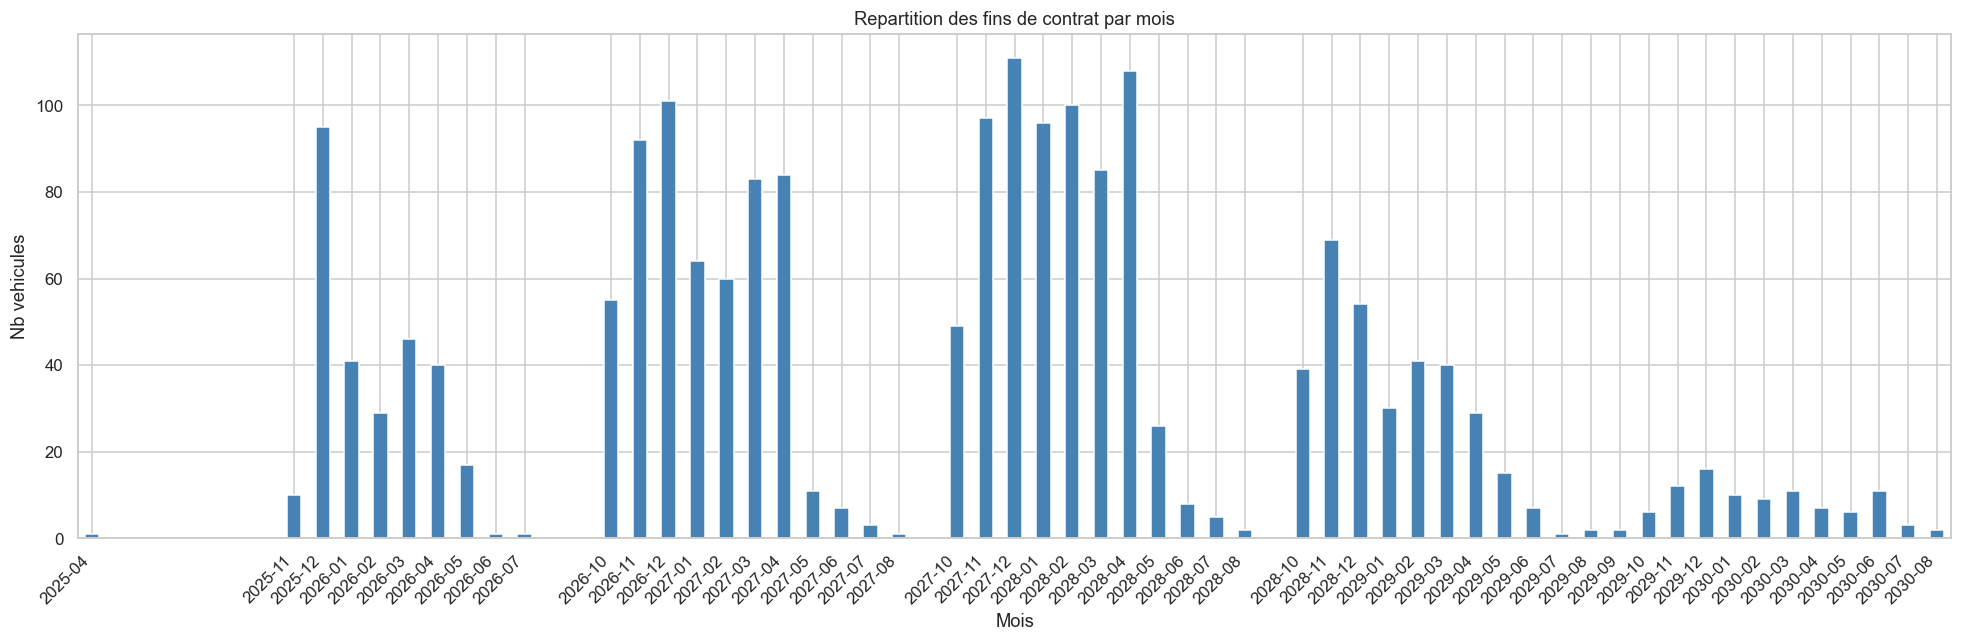

In [175]:
 if 'end_date' in pf.columns:
    print('Plage des dates de fin de contrat :')
    print(f'  Min : {pf["end_date"].min().date()}')
    print(f'  Max : {pf["end_date"].max().date()}')

    pf['end_year_month'] = pf['end_date'].dt.to_period('M')
    fig, ax = plt.subplots(figsize=(18, 6))
    pf['end_year_month'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Repartition des fins de contrat par mois')
    ax.set_xlabel('Mois')
    ax.set_ylabel('Nb vehicules')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Le portfolio couvre une plage allant d'avril 2025 à août 2030, soit un horizon
de prédiction de 5 ans. C'est une contrainte importante car le modèle devra
estimer des prix sur un marché futur qu'il n'a pas encore observé.

Les fins de contrat se répartissent en 4 vagues distinctes centrées sur
2025-2026, 2026-2027, 2027-2028 et 2028-2029, chacune représentant une
génération de contrats signés avec des durées similaires (48 ou 60 mois).

Les contrats finissant en 2029-2030 sont peu représentés, correspondant
aux contrats les plus longs du portfolio.

> **Point d'attention** : c'est possible que les prédictions pour 2028-2030 soient
> les moins fiables car elles extrapolent le plus loin de la fenêtre
> d'entraînement (2018-2025). 

### Synthese EDA

| Observation | Implication pour la modelisation |
|---|---|
| Distribution de `sale_price` asymetrique a droite | Envisager une transformation log ou cibler MAPE |
| Forte depreciation dans les 24 premiers mois | `age_months` est la feature dominante |
| Electriques depreciient differemment des thermiques | `fuel_type` est un feature discriminant cle |
| `list_price` tres correle a `sale_price` | Feature puissante — attention a l'effet look-ahead pour le portfolio |
| Pas de valeurs manquantes declarees dans used_market | Validation a confirmer apres renommage |

**Prochaine etape : Feature Engineering (Cellule 3)**

## Feature Engineering & Projection Portfolio

#### 3.0 Correction du rename manqué (Engine Power HP — casse différente) 

In [176]:
if 'Engine Power (HP)' in mkt.columns:
    mkt = mkt.rename(columns={'Engine Power (HP)': 'engine_hp'})
    mkt['engine_hp'] = pd.to_numeric(mkt['engine_hp'], errors='coerce')
    print('Rename engine_hp OK')

# Normalisation de la casse sur les colonnes texte
for col in ['brand', 'model', 'fuel_type', 'range_type', 'model_segment', 'body_type', 'gearbox']:
    if col in mkt.columns:
        mkt[col] = mkt[col].astype(str).str.strip().str.upper()

print('Colonnes disponibles :', [c for c in mkt.columns if c in
      ['brand','model','fuel_type','range_type','engine_hp','gearbox',
       'body_type','model_segment','mileage','age_months','sale_price','list_price']])

Rename engine_hp OK
Colonnes disponibles : ['brand', 'model', 'range_type', 'fuel_type', 'engine_hp', 'gearbox', 'body_type', 'model_segment', 'mileage', 'age_months', 'sale_price', 'list_price']


####  3.1 Features dérivées sur used_market 

In [177]:
# Ratio de dépréciation observé (analyse uniquement)
mkt['vr_ratio'] = mkt['sale_price'] / mkt['list_price'].replace(0, np.nan)

# Intensité d'usage (km/mois)
mkt['mileage_per_month'] = mkt['mileage'] / mkt['age_months'].replace(0, np.nan)

# Transformations log
mkt['log_list_price'] = np.log1p(mkt['list_price'])
mkt['log_age']        = np.log1p(mkt['age_months'])
mkt['log_mileage']    = np.log1p(mkt['mileage'])

# Terme quadratique sur l'âge (capture la non-linéarité de la dépréciation)
mkt['age_sq'] = mkt['age_months'] ** 2

# Interaction âge × kilométrage (double usure)
mkt['age_x_mileage'] = (mkt['age_months'] / 12) * (mkt['mileage'] / 10_000)

# Variable cible log (pour le modèle Ridge)
mkt['log_sale_price'] = np.log1p(mkt['sale_price'])

new_feats = ['vr_ratio','mileage_per_month','log_list_price','log_age',
             'log_mileage','age_sq','age_x_mileage','log_sale_price']
print('Features créées sur used_market :')
display(mkt[new_feats].describe().T[['mean','std','min','max']])

Features créées sur used_market :


,mean,std,min,max
vr_ratio,0.49,0.18,0.04,1.03
mileage_per_month,1189.43,910.48,41.67,10000.00
log_list_price,9.86,0.40,8.66,11.95
log_age,3.78,0.86,0.69,4.80
log_mileage,10.57,1.03,8.52,12.21
age_sq,4193.70,3972.86,1.00,14400.00
age_x_mileage,35.64,38.50,0.04,200.00
log_sale_price,9.07,0.61,5.89,11.67


**vr_ratio** (sale_price / list_price)

Représente le taux de rétention de valeur du véhicule. Une moyenne de 0.49
signifie qu'un véhicule vaut en moyenne 49% de son prix neuf au moment de la
revente. Le min à 0.04 (4% du prix neuf) et le max à 1.03 (légèrement au-dessus
du prix neuf, cas marginaux sur véhicules très récents) confirment la cohérence
des données. Cette variable est utilisée uniquement pour l'analyse, pas comme
feature du modèle car elle introduirait une fuite d'information (elle contient
sale_price).

**mileage_per_month**

Intensité d'usage en km/mois. La moyenne à 1 189 km/mois (soit ~14 300 km/an)
est cohérente avec le marché allemand. La forte dispersion (std de 910) reflète
des profils d'usage très hétérogènes entre conducteurs.

**log_list_price, log_age, log_mileage**

Transformations logarithmiques des trois variables continues principales. Elles
linearisent les relations avec log_sale_price et réduisent l'influence des
valeurs extrêmes, ce qui est particulièrement utile pour Ridge/Lasso.

**age_sq**

Terme quadratique sur l'âge pour capturer la non-linéarité de la dépréciation :
un véhicule se déprécie plus vite en début de vie qu'en fin. La forte std
(3 973) par rapport à la moyenne (4 194) confirme la grande variabilité d'âge
dans le dataset.

**age_x_mileage**

Terme d'interaction entre l'âge (en années) et le kilométrage (en dizaines de
milliers). Capture la double usure : un véhicule vieux ET très roulé se
déprécie plus que la somme des deux effets séparés. La moyenne à 35.6 et le
max à 200 (10 ans x 200 000 km / 10 000) sont cohérents avec les bornes du
dataset.

**log_sale_price**

Variable cible transformée pour le modèle Ridge/Lasso. Centrée sur 9.07
(soit e^9.07 ~ 8 700 €), proche de la médiane observée, avec une distribution
quasi-gaussienne vue en section 2.1.

#### 3.2 Projection portfolio : âge et km à la date de fin de contrat 


In [178]:
# age_months_at_end = initial_car_age (mois) + contract_duration (mois)

pf['age_months'] = pf['initial_age'] + pf['contract_duration']

# mileage_at_end    = initial_mileage + contract_mileage (km total contracté)

pf['mileage']    = pf['initial_mileage'] + pf['contract_mileage']

print('=== Vérification projection portfolio ===')
print(pf[['id','initial_age','contract_duration','age_months',
          'initial_mileage','contract_mileage','mileage']].head(8).to_string(index=False))

print(f'\nAge projeté (mois)  — médiane: {pf["age_months"].median():.0f}  '
      f'min: {pf["age_months"].min()}  max: {pf["age_months"].max()}')
print(f'Km projeté (km)     — médiane: {pf["mileage"].median():,.0f}  '
      f'min: {pf["mileage"].min():,}  max: {pf["mileage"].max():,}')

=== Vérification projection portfolio ===
 id  initial_age  contract_duration  age_months  initial_mileage  contract_mileage  mileage
  1            0                 48          48                0             50042    50042
  2            0                 60          60                0             50025    50025
  3            1                 36          37               45             30023    30068
  4            0                 61          61                0            100021   100021
  5            0                 61          61                0             50011    50011
  6            0                 60          60                0             50032    50032
  7            0                 60          60                0             62541    62541
  8            0                 60          60                0             75029    75029

Age projeté (mois)  — médiane: 60  min: 8  max: 64
Km projeté (km)     — médiane: 50,021  min: 7,505  max: 175,049


####  3.3 Normalisation casse + vérif alignement des modalités 

In [179]:
for col in ['brand', 'model', 'fuel_type', 'range_type']:
    if col in pf.columns:
        pf[col] = pf[col].astype(str).str.strip().str.upper()

print('fuel_type mkt      :', sorted(mkt['fuel_type'].unique()))
print('fuel_type portfolio:', sorted(pf['fuel_type'].unique()))

fuel_type mkt      : ['DIESEL', 'ELECTRIC', 'PETROL', 'PETROL HEV', 'PETROL LPG', 'PETROL PHEV']
fuel_type portfolio: ['DIESEL', 'ELECTRIC', 'PETROL', 'PETROL HEV', 'PETROL LPG', 'PETROL PHEV']


In [180]:
# ── 3.4 Enrichissement portfolio avec les features absentes ──────────────────
# Le portfolio n'a pas : engine_hp, model_segment, body_type, gearbox
# On les impute depuis used_market via (brand, model, fuel_type, range_type)

lookup_cols  = ['engine_hp', 'model_segment', 'body_type', 'gearbox']
avail_lookup = [c for c in lookup_cols if c in mkt.columns]
group_keys   = ['brand', 'model', 'fuel_type', 'range_type']

def agg_mode(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

agg_dict = {}
for c in avail_lookup:
    agg_dict[c] = 'median' if mkt[c].dtype in ['float64','int64','float32','int32'] else agg_mode

lookup = mkt.groupby(group_keys, observed=True).agg(agg_dict).reset_index()

pf_enriched = pf.merge(lookup, on=group_keys, how='left')

print('Taux de couverture de l\'enrichissement :')
for col in avail_lookup:
    n = pf_enriched[col].notna().sum()
    print(f'  {col:15s} {n}/{len(pf_enriched)} ({n/len(pf_enriched)*100:.1f}%)')

Taux de couverture de l'enrichissement :
  engine_hp       1945/1951 (99.7%)
  model_segment   1945/1951 (99.7%)
  body_type       1945/1951 (99.7%)
  gearbox         1945/1951 (99.7%)


In [181]:
# ── 3.5 Features dérivées sur le portfolio enrichi ────────────────────────────
pf_enriched['mileage_per_month'] = pf_enriched['mileage'] / pf_enriched['age_months'].replace(0, np.nan)
pf_enriched['log_list_price']    = np.log1p(pf_enriched['list_price'])
pf_enriched['log_age']           = np.log1p(pf_enriched['age_months'])
pf_enriched['log_mileage']       = np.log1p(pf_enriched['mileage'])
pf_enriched['age_sq']            = pf_enriched['age_months'] ** 2
pf_enriched['age_x_mileage']     = (pf_enriched['age_months'] / 12) * (pf_enriched['mileage'] / 10_000)

print(f'Portfolio enrichi : {pf_enriched.shape}')
display(pf_enriched[['id','brand','model','fuel_type','age_months','mileage',
                      'list_price','engine_hp','model_segment']].head(6))

Portfolio enrichi : (1951, 32)


,id,brand,model,fuel_type,age_months,mileage,list_price,engine_hp,model_segment
0,1,RENAULT,KANGOO,PETROL,48,50042,19440.00,113.00,LCV
1,2,RENAULT,SCENIC,PETROL,60,50025,30000.00,130.00,C
2,3,RENAULT,CLIO,PETROL,37,30068,15924.37,89.00,B
3,4,DACIA,DUSTER,PETROL LPG,61,100021,14193.28,103.00,C
4,5,DACIA,SPRING,ELECTRIC,61,50011,18310.92,44.00,A
5,6,DACIA,SPRING,ELECTRIC,60,50032,18563.03,44.00,A


In [182]:
# ── 3.6 Définition des features finales du modèle ────────────────────────────
NUM_FEATURES = [
    'age_months',        # dépréciation temporelle
    'mileage',           # usure kilométrique
    'list_price',        # ancre de valeur (corrélation 0.785)
    'engine_hp',         # puissance → segment de prix
    'mileage_per_month', # intensité d'usage
    'age_sq',            # non-linéarité de la dépréciation
    'age_x_mileage',     # double usure
    'log_list_price',
    'log_age',
    'log_mileage',
]

CAT_FEATURES = [
    'brand',
    'fuel_type',
    'range_type',
    'model_segment',
    'body_type',
    'gearbox',
]

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

print('Disponibilité des features :')
for col in ALL_FEATURES:
    ok_mkt = col in mkt.columns
    ok_pf  = col in pf_enriched.columns
    status = 'OK' if (ok_mkt and ok_pf) else ('absent MKT' if not ok_mkt else 'absent PF')
    print(f'  {col:22s}  mkt={str(ok_mkt):5s}  pf={str(ok_pf):5s}  [{status}]')

Disponibilité des features :
  age_months              mkt=True   pf=True   [OK]
  mileage                 mkt=True   pf=True   [OK]
  list_price              mkt=True   pf=True   [OK]
  engine_hp               mkt=True   pf=True   [OK]
  mileage_per_month       mkt=True   pf=True   [OK]
  age_sq                  mkt=True   pf=True   [OK]
  age_x_mileage           mkt=True   pf=True   [OK]
  log_list_price          mkt=True   pf=True   [OK]
  log_age                 mkt=True   pf=True   [OK]
  log_mileage             mkt=True   pf=True   [OK]
  brand                   mkt=True   pf=True   [OK]
  fuel_type               mkt=True   pf=True   [OK]
  range_type              mkt=True   pf=True   [OK]
  model_segment           mkt=True   pf=True   [OK]
  body_type               mkt=True   pf=True   [OK]
  gearbox                 mkt=True   pf=True   [OK]


In [183]:
# 3.7 Reconstruction dates + Nouvelle target VR ratio + Filtre

# sale_date already datetime from cleaning step (utils_fonctions)
mkt['sale_date_fixed'] = mkt['sale_date']
print('Dates disponibles :')
print(mkt['sale_date_fixed'].dt.year.value_counts().sort_index().to_string())

# Nouvelle target : VR ratio = sale_price / list_price
mkt['vr_ratio'] = mkt['sale_price'] / mkt['list_price'].replace(0, float('nan'))

# Filtre : vr_ratio > 1 = revendu plus cher que neuf -> exclusion
n_before = len(mkt)
mkt_train = mkt[(mkt['vr_ratio'] <= 1.0) & (mkt['vr_ratio'] > 0)].copy()
print(f'Lignes retirees (vr_ratio hors ]0,1]) : {n_before - len(mkt_train):,}  ({(n_before - len(mkt_train))/n_before*100:.2f}%)')
print(f'mkt_train : {len(mkt_train):,} lignes')
print(f'vr_ratio  : min={mkt_train["vr_ratio"].min():.4f}  median={mkt_train["vr_ratio"].median():.4f}  mean={mkt_train["vr_ratio"].mean():.4f}  max={mkt_train["vr_ratio"].max():.4f}')

# Imputation NaN
for col in NUM_FEATURES:
    if col in mkt_train.columns:
        n_nan = mkt_train[col].isna().sum()
        if n_nan > 0:
            fill = mkt_train.groupby('fuel_type')[col].transform('median')
            mkt_train[col] = mkt_train[col].fillna(fill).fillna(mkt_train[col].median())
            print(f'  Imputation {col}: {n_nan} NaN')
for col in CAT_FEATURES:
    if col in mkt_train.columns:
        mkt_train[col] = mkt_train[col].fillna('UNKNOWN')
for col in NUM_FEATURES:
    if col in pf_enriched.columns:
        fill = pf_enriched.groupby('fuel_type')[col].transform('median')
        pf_enriched[col] = pf_enriched[col].fillna(fill).fillna(mkt_train[col].median())
for col in CAT_FEATURES:
    if col in pf_enriched.columns:
        pf_enriched[col] = pf_enriched[col].fillna('UNKNOWN')

nan_check = mkt_train[ALL_FEATURES].isna().sum()
remaining  = nan_check[nan_check > 0]
print('NaN residuels :', 'aucun' if not len(remaining) else '')
if len(remaining):
    display(remaining.to_frame('nb_NaN'))

Dates disponibles :
sale_date_fixed
2018    127067
2019    110024
2020    104862
2021     87956
2022     75432
2023     75149
2024     78671
2025     77797
Lignes retirees (vr_ratio hors ]0,1]) : 11  (0.00%)
mkt_train : 736,947 lignes
vr_ratio  : min=0.0364  median=0.4839  mean=0.4905  max=0.9961
NaN residuels : aucun


In [184]:
# 3.8 Encodage : OrdinalEncoder (XGBoost) + raw strings (CatBoost)
from sklearn.preprocessing import OrdinalEncoder

cat_avail = [c for c in CAT_FEATURES if c in mkt_train.columns]
oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
oe.fit(mkt_train[cat_avail])

# Dataset XGBoost (ordinal encoding)
X_mkt = mkt_train[NUM_FEATURES + cat_avail].copy()
X_mkt[cat_avail] = oe.transform(X_mkt[cat_avail])

# Target : vr_ratio
y_mkt = mkt_train["vr_ratio"].values

# Dataset CatBoost (categories en string)
X_mkt_cat = mkt_train[NUM_FEATURES + cat_avail].copy()

# Portfolio encode
cat_pf_avail = [c for c in cat_avail if c in pf_enriched.columns]
X_pf     = pf_enriched[NUM_FEATURES + cat_pf_avail].copy()
X_pf[cat_pf_avail] = oe.transform(pf_enriched[cat_pf_avail])
X_pf_cat = pf_enriched[NUM_FEATURES + cat_pf_avail].copy()

print(f'X_mkt : {X_mkt.shape}   y_mkt (vr_ratio) : min={y_mkt.min():.4f}  max={y_mkt.max():.4f}  mean={y_mkt.mean():.4f}')
print(f'X_pf  : {X_pf.shape}')
display(X_mkt.head(3))

X_mkt : (736947, 16)   y_mkt (vr_ratio) : min=0.0364  max=0.9961  mean=0.4905
X_pf  : (1951, 16)


,age_months,mileage,list_price,engine_hp,mileage_per_month,age_sq,age_x_mileage,log_list_price,log_age,log_mileage,brand,fuel_type,range_type,model_segment,body_type,gearbox
0,120,75000,6675,74,625.00,14400,75.00,8.81,4.80,11.23,0.00,2.00,1.00,1.00,5.00,1.00
1,108,30000,7055,74,277.78,11664,27.00,8.86,4.69,10.31,0.00,2.00,1.00,1.00,5.00,1.00
2,120,75000,6449,74,625.00,14400,75.00,8.77,4.80,11.23,0.00,2.00,1.00,1.00,5.00,1.00


In [186]:
# 3.9 Split TEMPOREL : train 2018-2023 / test 2024-2025
# Plus realiste qu un random split pour valider la generalisation future

cutoff     = pd.Timestamp("2024-01-01")
train_mask = mkt_train["sale_date_fixed"] < cutoff
test_mask  = mkt_train["sale_date_fixed"] >= cutoff

X_train     = X_mkt[train_mask.values]
X_test      = X_mkt[test_mask.values]
y_train     = y_mkt[train_mask.values]
y_test      = y_mkt[test_mask.values]
X_train_cat = X_mkt_cat[train_mask.values]
X_test_cat  = X_mkt_cat[test_mask.values]
# Precompute list_price arrays aligned to train/test splits
lp_train    = mkt_train["list_price"].values[train_mask.values]
lp_test     = mkt_train["list_price"].values[test_mask.values]
# Use .values to avoid pandas 3.x boolean-Series indexing quirks
train_idx   = mkt_train.index[train_mask.values]
test_idx    = mkt_train.index[test_mask.values]

print(f"Train (2018-2023) : {len(X_train):,}  ({len(X_train)/len(X_mkt)*100:.1f}%)")
print(f"Test  (2024-2025) : {len(X_test):,}  ({len(X_test)/len(X_mkt)*100:.1f}%)")
print("Annees train :")
print(mkt_train.loc[train_idx, "sale_date_fixed"].dt.year.value_counts().sort_index().to_string())
print("Annees test :")
print(mkt_train.loc[test_idx, "sale_date_fixed"].dt.year.value_counts().sort_index().to_string())


Train (2018-2023) : 580,479  (78.8%)
Test  (2024-2025) : 156,468  (21.2%)
Annees train :
sale_date_fixed
2018    127064
2019    110024
2020    104861
2021     87954
2022     75429
2023     75147
Annees test :
sale_date_fixed
2024    78671
2025    77797


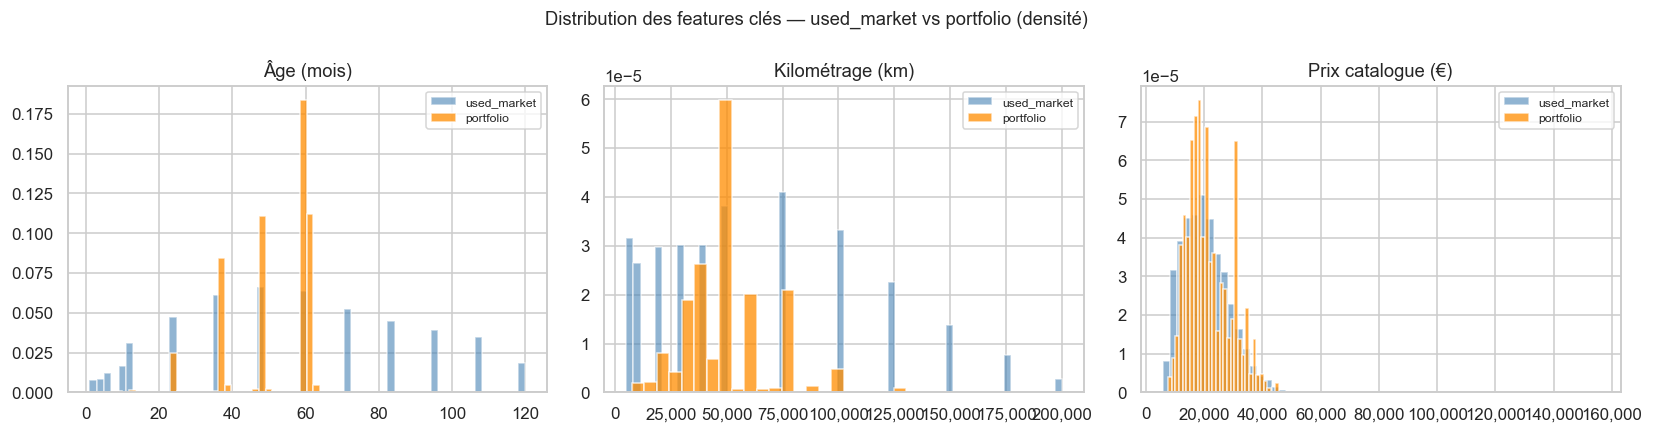

Résumé comparatif (médianes) :
  Âge (mois)            mkt=      60   portfolio=      60
  Km                    mkt=  50,000   portfolio=  50,021
  Prix catalogue        mkt=  19,706   portfolio=  19,992


In [187]:
# ── 3.10 Distribution des features clés : used_market vs portfolio ────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label in [
    (axes[0], 'age_months',  'Âge (mois)'),
    (axes[1], 'mileage',     'Kilométrage (km)'),
    (axes[2], 'list_price',  'Prix catalogue (€)'),
]:
    ax.hist(mkt_train[col], bins=60, alpha=0.6, color='steelblue',
            density=True, label='used_market')
    ax.hist(pf_enriched[col], bins=30, alpha=0.75, color='darkorange',
            density=True, label='portfolio')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribution des features clés — used_market vs portfolio (densité)', fontsize=12)
plt.tight_layout()
plt.show()

print('Résumé comparatif (médianes) :')
for col, label in [('age_months','Âge (mois)'),('mileage','Km'),('list_price','Prix catalogue')]:
    m = mkt_train[col].median()
    p = pf_enriched[col].median()
    print(f'  {label:20s}  mkt={m:>8,.0f}   portfolio={p:>8,.0f}')

### Récapitulatif Cellule 3

| Étape | Action |
|---|---|
| 3.0 | Correction rename `engine_hp` (bug casse) + normalisation texte en MAJUSCULES |
| 3.1 | 8 features dérivées sur used_market : `vr_ratio`, `mileage_per_month`, `age_sq`, `age_x_mileage`, 3 logs |
| 3.2 | Projection portfolio : `age_months = initial_age + contract_duration`, `mileage = initial_mileage + contract_mileage` |
| 3.3 | Vérification alignement des modalités fuel_type entre les deux datasets |
| 3.4 | Enrichissement portfolio : `engine_hp`, `model_segment`, `body_type`, `gearbox` imputés via lookup sur used_market |
| 3.5 | Mêmes features dérivées appliquées au portfolio enrichi |
| 3.6 | Définition des listes `NUM_FEATURES` (10) + `CAT_FEATURES` (6) |
| 3.7 | Filtre outliers p0.5/p99.5 + imputation NaN par médiane par fuel_type |
| 3.8 | OrdinalEncoder (pour LightGBM/XGBoost) — appliqué sur mkt et portfolio |
| 3.9 | Split 80/20 stratifié sur `fuel_type` |
| 3.10 | Comparaison distributions mkt vs portfolio sur les 3 features clés |

**Prochaine étape : Modèle 1 — Ridge régularisé (Cellule 4)**

---
## Variables externes — Suggestion (point 5)

| Variable | Impact sur VR | Source | Dispo |
|---|---|---|---|
| **Prix du carburant DE** | Hausse fuel => moins de demande diesel/essence => VR baisse | [CEIC Germany Gasoline Price](https://www.ceicdata.com/en/germany/gasoline-price) | Mensuel, libre |
| **Indice ifo Business Climate** | Confiance consommateurs => demande vehicules occasions | [Destatis / ifo Institute](https://www.ifo.de/en/survey/ifo-business-climate-index) | Mensuel, libre |
| **Taux d'immatriculations VE Allemagne** | Hausse VE => devaluation ICE a terme | [KBA Kraftfahrt-Bundesamt](https://www.kba.de/DE/Statistik/statistik_node.html) | Mensuel, libre |
| **Indice CPI Allemagne** | Inflation generale => impact prix occasions | [Eurostat / Destatis](https://www.destatis.de) | Mensuel, libre |
| **Volume de production automobile DE** | Penurie offre => VR montre (crise chips 2021-22) | [VDA / Eurostat](https://www.vda.de/en/topics/economic-reports) | Mensuel |
| **Dummy COVID** (2020-Q2/Q3) | Choc offre => VR monte +10-20% | Construit manuellement | — |
| **Dummy crise chips** (2021-2022) | Penurie neuf => VR occasion reste eleve | Construit manuellement | — |
| **Dummy guerre Ukraine** (fev 2022+) | Pic carburant, penurie cablage => impact diesel | Construit manuellement | — |

**Usage recommande :** Ces variables seraient ajoutees comme features temporelles (par annee-mois de vente) grace au `sale_date_fixed` que nous venons de reconstruire. Elles ne sont **pas encore integrees** dans les modeles actuels — on travaille d'abord sur les donnees disponibles avant de les enrichir.

---
## Cellule 4 — Clustering par profil de depreciation

In [188]:
# ── 4.1 Profil de depreciation par groupe (fuel_type x model_segment) ────────
# Pour chaque groupe, on calcule le VR ratio median sur 4 tranches d'age
# => chaque groupe = vecteur 4D de depreciation => KMeans k=4

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

AGE_BINS   = [0, 24, 48, 72, 120]
BIN_LABELS = ['0-24m', '24-48m', '48-72m', '72+m']

mkt_train['age_bin_cl'] = pd.cut(mkt_train['age_months'],
                                  bins=AGE_BINS, labels=BIN_LABELS, right=False)

# Profil median de VR ratio par (fuel_type, model_segment, tranche d'age)
GROUP_KEYS = ['fuel_type', 'model_segment']
profile = (
    mkt_train.groupby(GROUP_KEYS + ['age_bin_cl'], observed=True)['vr_ratio']
    .median()
    .unstack('age_bin_cl')
    .reset_index()
)

# Remplissage des NaN (groupes sans transactions sur certaines tranches)
bin_cols = [c for c in BIN_LABELS if c in profile.columns]
profile[bin_cols] = (profile[bin_cols]
                     .ffill(axis=1)
                     .bfill(axis=1)
                     .fillna(profile[bin_cols].mean()))

profile = profile.dropna(subset=bin_cols)
print(f'Nombre de groupes (fuel_type x model_segment) : {len(profile)}')
display(profile.head(8))

# Normalisation + KMeans k=4
scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(profile[bin_cols])
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=30)
profile['cluster'] = kmeans.fit_predict(X_cl)

print(f'\nInertie KMeans (k={K}) : {kmeans.inertia_:.4f}')
print('\nRepartition par cluster :')
print(profile['cluster'].value_counts().sort_index().to_string())

Nombre de groupes (fuel_type x model_segment) : 28


age_bin_cl,fuel_type,model_segment,0-24m,24-48m,48-72m,72+m
0,DIESEL,A,0.18,0.18,0.18,0.18
1,DIESEL,B,0.67,0.51,0.42,0.35
2,DIESEL,C,0.69,0.52,0.41,0.31
3,DIESEL,D,0.68,0.54,0.42,0.29
4,DIESEL,E,0.69,0.56,0.42,0.33
5,DIESEL,LCV,0.66,0.54,0.42,0.35
6,ELECTRIC,A,0.64,0.46,0.37,0.37
7,ELECTRIC,B,0.66,0.47,0.36,0.27



Inertie KMeans (k=4) : 18.9994

Repartition par cluster :
cluster
0     9
1     1
2     1
3    17


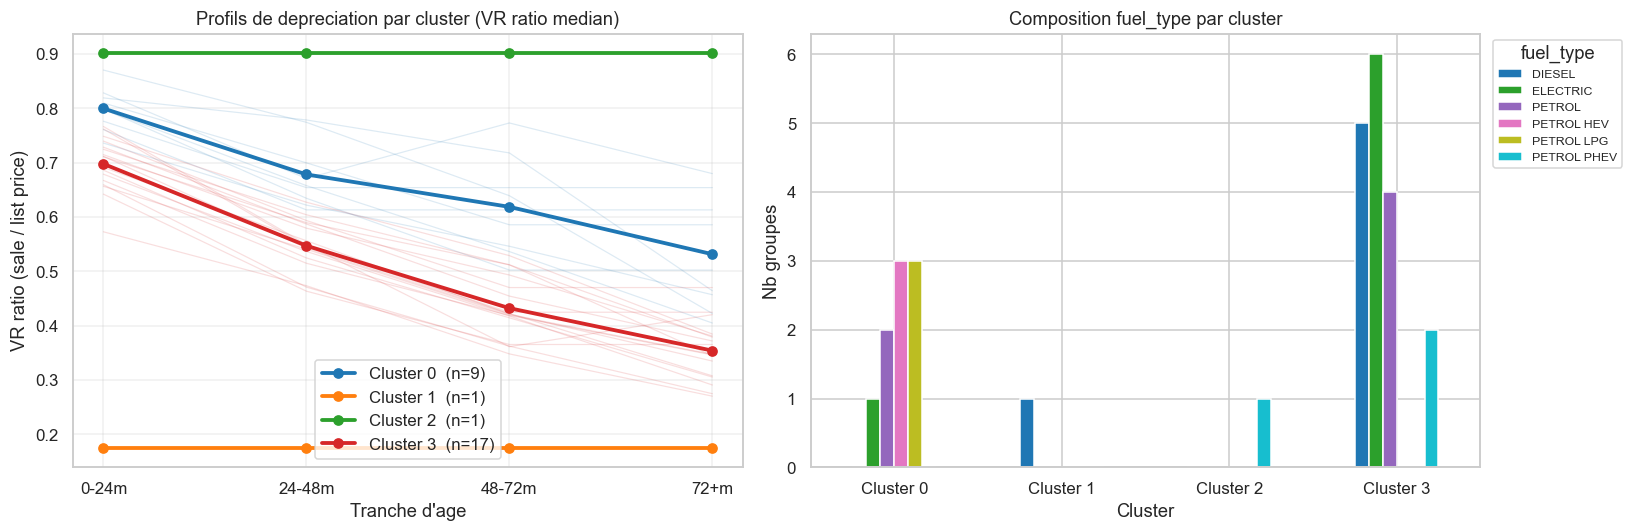


=== Description des clusters ===


age_bin_cl,0-24m,24-48m,48-72m,72+m,nb_groupes
cluster,,,,,
0,0.80,0.68,0.62,0.53,9
1,0.18,0.18,0.18,0.18,1
2,0.90,0.90,0.90,0.90,1
3,0.70,0.55,0.43,0.35,17


In [189]:
# ── 4.2 Visualisation des clusters ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Courbes de depreciation par cluster
ax = axes[0]
colors_cl = sns.color_palette('tab10', K)
for cl in range(K):
    sub = profile[profile['cluster'] == cl]
    mean_profile = sub[bin_cols].mean()
    ax.plot(range(len(bin_cols)), mean_profile.values,
            marker='o', color=colors_cl[cl], linewidth=2.5,
            label=f'Cluster {cl}  (n={len(sub)})')
    # Lignes individuelles en transparence
    for _, row in sub.iterrows():
        ax.plot(range(len(bin_cols)), row[bin_cols].values,
                color=colors_cl[cl], alpha=0.15, linewidth=0.8)

ax.set_xticks(range(len(bin_cols)))
ax.set_xticklabels(bin_cols)
ax.set_title('Profils de depreciation par cluster (VR ratio median)')
ax.set_ylabel('VR ratio (sale / list price)')
ax.set_xlabel('Tranche d\'age')
ax.legend()
ax.grid(True, alpha=0.3)

# Composition fuel_type par cluster
ax = axes[1]
comp = profile.groupby(['cluster', 'fuel_type']).size().unstack(fill_value=0)
comp.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Composition fuel_type par cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Nb groupes')
ax.set_xticklabels([f'Cluster {i}' for i in range(K)], rotation=0)
ax.legend(title='fuel_type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Description des clusters
print('\n=== Description des clusters ===')
cl_desc = profile.groupby('cluster')[bin_cols].mean()
cl_desc['nb_groupes'] = profile.groupby('cluster').size()
display(cl_desc.round(3))

In [191]:
# ── 4.3 Assignation des clusters a chaque transaction ────────────────────────
# Merge cluster label sur (fuel_type, model_segment)
cluster_map = profile[GROUP_KEYS + ["cluster"]].copy()

mkt_train = mkt_train.drop(columns=["cluster"], errors="ignore")
pf_enriched = pf_enriched.drop(columns=["cluster"], errors="ignore")
mkt_train = mkt_train.merge(cluster_map, on=GROUP_KEYS, how="left")
mkt_train["cluster"] = mkt_train["cluster"].fillna(-1).astype(int)

# Assignation au portfolio
pf_enriched = pf_enriched.merge(cluster_map, on=GROUP_KEYS, how="left")
pf_enriched["cluster"] = pf_enriched["cluster"].fillna(-1).astype(int)

# merge() resets the index to RangeIndex -> recompute all split arrays
mkt_train = mkt_train.reset_index(drop=True)
cat_avail = [c for c in CAT_FEATURES if c in mkt_train.columns]
X_mkt     = mkt_train[NUM_FEATURES + cat_avail].copy()
X_mkt[cat_avail] = oe.transform(X_mkt[cat_avail])
X_mkt_cat = mkt_train[NUM_FEATURES + cat_avail].copy()
y_mkt     = mkt_train["vr_ratio"].values

cutoff      = pd.Timestamp("2024-01-01")
train_mask  = mkt_train["sale_date_fixed"] < cutoff
test_mask   = mkt_train["sale_date_fixed"] >= cutoff
X_train     = X_mkt[train_mask.values]
X_test      = X_mkt[test_mask.values]
y_train     = y_mkt[train_mask.values]
y_test      = y_mkt[test_mask.values]
X_train_cat = X_mkt_cat[train_mask.values]
X_test_cat  = X_mkt_cat[test_mask.values]
lp_train    = mkt_train["list_price"].values[train_mask.values]
lp_test     = mkt_train["list_price"].values[test_mask.values]
train_idx   = mkt_train.index[train_mask.values]
test_idx    = mkt_train.index[test_mask.values]

print("Repartition des clusters dans mkt_train :")
print(mkt_train["cluster"].value_counts().sort_index().to_string())
print("Repartition dans le portfolio :")
print(pf_enriched["cluster"].value_counts().sort_index().to_string())
print(f"Vehicules portfolio sans cluster (cluster=-1) : {(pf_enriched["cluster"]==-1).sum()}")


Repartition des clusters dans mkt_train :
cluster
0     23115
1       145
2        62
3    713625
Repartition dans le portfolio :
cluster
-1       6
 0     258
 3    1687
Vehicules portfolio sans cluster (cluster=-1) : 6


---
## Cellule 5 — XGBoost (global + par cluster)

In [192]:
# ── 5.0 Fonction d'evaluation (VR ratio + euros) ─────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

def evaluate_vr(y_true_ratio, y_pred_ratio, list_prices, label=''):
    """Evalue sur le VR ratio ET en euros (pred * list_price)."""
    # Metriques sur le ratio
    mae_r  = mean_absolute_error(y_true_ratio, y_pred_ratio)
    r2_r   = r2_score(y_true_ratio, y_pred_ratio)
    # Metriques en euros
    y_true_eur = y_true_ratio * list_prices
    y_pred_eur = y_pred_ratio * list_prices
    mae_e  = mean_absolute_error(y_true_eur, y_pred_eur)
    rmse_e = mean_squared_error(y_true_eur, y_pred_eur) ** 0.5
    mape_e = np.mean(np.abs((y_true_eur - y_pred_eur) / np.clip(y_true_eur, 1, None))) * 100
    print(f'  {label:35s}  MAE_ratio={mae_r:.5f}  R2={r2_r:.4f}  '
          f'MAE_eur={mae_e:>6,.0f}EUR  RMSE={rmse_e:>7,.0f}EUR  MAPE={mape_e:.2f}%')
    return {'label': label, 'MAE_ratio': mae_r, 'R2': r2_r,
            'MAE_eur': mae_e, 'RMSE_eur': rmse_e, 'MAPE': mape_e}

# Recuperer list_price du test set
lp_test = mkt_train["list_price"].values[test_mask.values]

results_all = []

# ── 5.1 XGBoost global (benchmark) ───────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators=2000, learning_rate=0.05, max_depth=6,
    min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
    early_stopping_rounds=100, eval_metric='mae', verbosity=0,
)

xgb_global = XGBRegressor(**XGB_PARAMS)
xgb_global.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_xgb_global = np.clip(xgb_global.predict(X_test), 0, 1)
print('=== XGBoost GLOBAL ===')
r = evaluate_vr(y_test, y_pred_xgb_global, lp_test, 'XGBoost global')
results_all.append(r)
print(f'  Nb arbres optimal : {xgb_global.best_iteration}')


=== XGBoost GLOBAL ===
  XGBoost global                       MAE_ratio=0.05411  R2=0.8148  MAE_eur= 1,200EUR  RMSE=  1,671EUR  MAPE=11.39%
  Nb arbres optimal : 1992


In [193]:
# ── 5.2 XGBoost par cluster ───────────────────────────────────────────────────
clusters_train = mkt_train["cluster"].values[train_mask.values]
clusters_test  = mkt_train["cluster"].values[test_mask.values]

xgb_per_cluster = {}
y_pred_xgb_cl   = np.zeros(len(X_test))

print("=== XGBoost PAR CLUSTER ===")
for cl in sorted(set(clusters_train)):
    tr_mask = clusters_train == cl
    te_mask = clusters_test  == cl
    if tr_mask.sum() < 100:
        print(f"  Cluster {cl} : trop peu de donnees ({tr_mask.sum()}), skip")
        continue
    if te_mask.sum() == 0:
        print(f"  Cluster {cl} : aucune donnee test, skip evaluation")
        # Train quand meme pour la prediction portfolio
        Xtr = X_train[tr_mask]; ytr = y_train[tr_mask]
        params_cl = {**XGB_PARAMS, "n_estimators": 500}
        m = XGBRegressor(**{k: v for k, v in params_cl.items() if k not in ["early_stopping_rounds", "eval_metric"]})
        m.fit(Xtr, ytr, verbose=False)
        xgb_per_cluster[cl] = m
        continue

    Xtr = X_train[tr_mask];  ytr = y_train[tr_mask]
    Xte = X_test[te_mask];   yte = y_test[te_mask]

    params_cl = {**XGB_PARAMS, "n_estimators": 1500}
    m = XGBRegressor(**params_cl)
    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    preds = np.clip(m.predict(Xte), 0, 1)
    y_pred_xgb_cl[te_mask] = preds
    xgb_per_cluster[cl] = m

    lp_cl = lp_test[te_mask]
    evaluate_vr(yte, preds, lp_cl, f"  Cluster {cl}  (n_train={tr_mask.sum():,})")

# Score global reconstitue
print()
r = evaluate_vr(y_test, y_pred_xgb_cl, lp_test, "XGBoost par cluster (global)")
results_all.append(r)


=== XGBoost PAR CLUSTER ===
    Cluster 0  (n_train=13,604)        MAE_ratio=0.05592  R2=0.7375  MAE_eur= 1,616EUR  RMSE=  2,315EUR  MAPE=8.67%
  Cluster 1 : aucune donnee test, skip evaluation
    Cluster 3  (n_train=566,730)       MAE_ratio=0.05410  R2=0.8035  MAE_eur= 1,171EUR  RMSE=  1,623EUR  MAPE=11.51%

  XGBoost par cluster (global)         MAE_ratio=0.05454  R2=0.8020  MAE_eur= 1,213EUR  RMSE=  1,856EUR  MAPE=11.38%


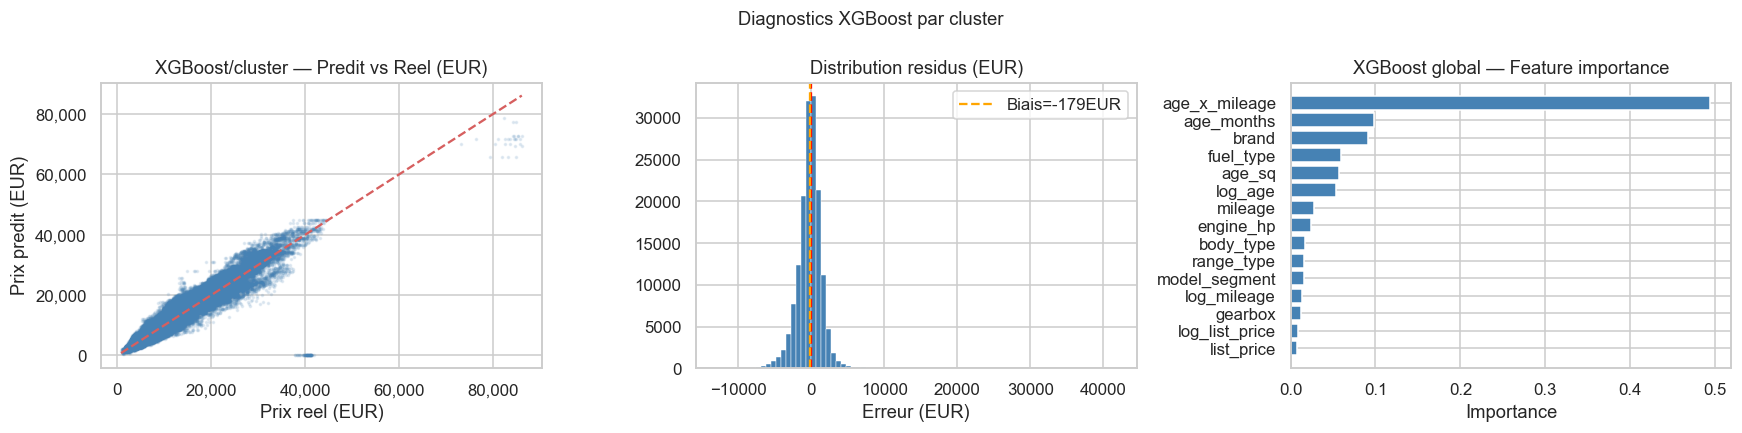

Biais moyen : -179EUR  |  Erreurs > 20% : 15.9%  |  Erreurs > 30% : 5.7%


In [194]:
# ── 5.3 Residus XGBoost + Feature importance ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

lp_t = lp_test
y_eur_true = y_test * lp_t
y_eur_pred = y_pred_xgb_cl * lp_t
residuals  = y_eur_true - y_eur_pred
rel_err    = residuals / np.clip(y_eur_true, 1, None) * 100

# Predit vs Reel (en euros)
ax = axes[0]
lims = [y_eur_true.min(), y_eur_true.max()]
ax.scatter(y_eur_true, y_eur_pred, s=2, alpha=0.12, color='steelblue')
ax.plot(lims, lims, 'r--', linewidth=1.5)
ax.set_title('XGBoost/cluster — Predit vs Reel (EUR)')
ax.set_xlabel('Prix reel (EUR)')
ax.set_ylabel('Prix predit (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Distribution residus
ax = axes[1]
ax.hist(residuals, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Biais={residuals.mean():.0f}EUR')
ax.set_title('Distribution residus (EUR)')
ax.set_xlabel('Erreur (EUR)')
ax.legend()

# Feature importance (modele global XGBoost)
ax = axes[2]
fi = pd.Series(xgb_global.feature_importances_, index=X_train.columns)
fi = fi.sort_values(ascending=False).head(15)
ax.barh(fi.index, fi.values, color='steelblue')
ax.set_title('XGBoost global — Feature importance')
ax.set_xlabel('Importance')
ax.invert_yaxis()

plt.suptitle('Diagnostics XGBoost par cluster', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Biais moyen : {residuals.mean():.0f}EUR  |  '
      f'Erreurs > 20% : {(np.abs(rel_err)>20).mean()*100:.1f}%  |  '
      f'Erreurs > 30% : {(np.abs(rel_err)>30).mean()*100:.1f}%')

---
## Cellule 6 — CatBoost (global + par cluster)

In [195]:
# ── 6.1 CatBoost global ───────────────────────────────────────────────────────
# CatBoost gere nativement les categories (pas besoin d'OrdinalEncoder)
from catboost import CatBoostRegressor, Pool

# Indices des colonnes categorielles dans X_mkt_cat
cat_idx = [X_train_cat.columns.get_loc(c) for c in cat_avail if c in X_train_cat.columns]

CB_PARAMS = dict(
    iterations=2000, learning_rate=0.05, depth=6,
    loss_function='MAE', eval_metric='MAE',
    random_seed=42, thread_count=-1,
    early_stopping_rounds=100, verbose=200,
)

train_pool = Pool(X_train_cat, y_train, cat_features=cat_idx)
test_pool  = Pool(X_test_cat,  y_test,  cat_features=cat_idx)

cb_global = CatBoostRegressor(**CB_PARAMS)
cb_global.fit(train_pool, eval_set=test_pool)

y_pred_cb_global = np.clip(cb_global.predict(test_pool), 0, 1)
print('\n=== CatBoost GLOBAL ===')
r = evaluate_vr(y_test, y_pred_cb_global, lp_test, 'CatBoost global')
results_all.append(r)

0:	learn: 0.1435181	test: 0.1346931	best: 0.1346931 (0)	total: 252ms	remaining: 8m 23s
200:	learn: 0.0536112	test: 0.0926737	best: 0.0926737 (200)	total: 49.6s	remaining: 7m 23s
400:	learn: 0.0493486	test: 0.0828974	best: 0.0828974 (400)	total: 1m 42s	remaining: 6m 48s
600:	learn: 0.0468887	test: 0.0772340	best: 0.0772340 (600)	total: 2m 37s	remaining: 6m 5s
800:	learn: 0.0452136	test: 0.0737886	best: 0.0737886 (800)	total: 3m 30s	remaining: 5m 15s
1000:	learn: 0.0439548	test: 0.0712650	best: 0.0712650 (1000)	total: 4m 25s	remaining: 4m 24s
1200:	learn: 0.0430022	test: 0.0694019	best: 0.0694019 (1200)	total: 5m 18s	remaining: 3m 31s
1400:	learn: 0.0422403	test: 0.0681237	best: 0.0681211 (1398)	total: 6m 10s	remaining: 2m 38s
1600:	learn: 0.0415511	test: 0.0669564	best: 0.0669564 (1600)	total: 7m 3s	remaining: 1m 45s
1800:	learn: 0.0409022	test: 0.0659536	best: 0.0659536 (1800)	total: 7m 54s	remaining: 52.5s
1999:	learn: 0.0403721	test: 0.0654755	best: 0.0654755 (1999)	total: 8m 46s	rem

In [196]:
# ── 6.2 CatBoost par cluster ──────────────────────────────────────────────────
cb_per_cluster  = {}
y_pred_cb_cl    = np.zeros(len(X_test_cat))

print("=== CatBoost PAR CLUSTER ===")
for cl in sorted(set(clusters_train)):
    tr_mask = clusters_train == cl
    te_mask = clusters_test  == cl
    if tr_mask.sum() < 100:
        continue
    if te_mask.sum() == 0:
        print(f"  Cluster {cl} : aucune donnee test, skip evaluation")
        Xtr_c = X_train_cat[tr_mask]; ytr = y_train[tr_mask]
        tr_p = Pool(Xtr_c, ytr, cat_features=cat_idx)
        params_cl = {**CB_PARAMS, "iterations": 500, "verbose": 0, "early_stopping_rounds": None}
        m = CatBoostRegressor(**params_cl)
        m.fit(tr_p)
        cb_per_cluster[cl] = m
        continue

    Xtr_c = X_train_cat[tr_mask];  ytr = y_train[tr_mask]
    Xte_c = X_test_cat[te_mask];   yte = y_test[te_mask]

    tr_p = Pool(Xtr_c, ytr, cat_features=cat_idx)
    te_p = Pool(Xte_c, yte, cat_features=cat_idx)

    params_cl = {**CB_PARAMS, "iterations": 1500, "verbose": 0}
    m = CatBoostRegressor(**params_cl)
    m.fit(tr_p, eval_set=te_p)

    preds = np.clip(m.predict(te_p), 0, 1)
    y_pred_cb_cl[te_mask] = preds
    cb_per_cluster[cl] = m

    lp_cl = lp_test[te_mask]
    evaluate_vr(yte, preds, lp_cl, f"  Cluster {cl}  (n_train={tr_mask.sum():,})")

print()
r = evaluate_vr(y_test, y_pred_cb_cl, lp_test, "CatBoost par cluster (global)")
results_all.append(r)


=== CatBoost PAR CLUSTER ===
    Cluster 0  (n_train=13,604)        MAE_ratio=0.06079  R2=0.6889  MAE_eur= 1,801EUR  RMSE=  2,517EUR  MAPE=9.41%
  Cluster 1 : aucune donnee test, skip evaluation
    Cluster 3  (n_train=566,730)       MAE_ratio=0.09663  R2=0.4125  MAE_eur= 1,890EUR  RMSE=  2,400EUR  MAPE=18.11%

  CatBoost par cluster (global)        MAE_ratio=0.09476  R2=0.4517  MAE_eur= 1,900EUR  RMSE=  2,538EUR  MAPE=17.61%


---
## Cellule 7 — Comparaison globale + SHAP

,MAE_ratio,R2,MAE_eur,RMSE_eur,MAPE
label,,,,,
XGBoost global,0.05,0.81,1200.00,1671.00,11.39
XGBoost par cluster (global),0.05,0.80,1213.00,1856.00,11.38
CatBoost global,0.07,0.73,1386.00,1853.00,13.27
CatBoost par cluster (global),0.09,0.45,1900.00,2538.00,17.61


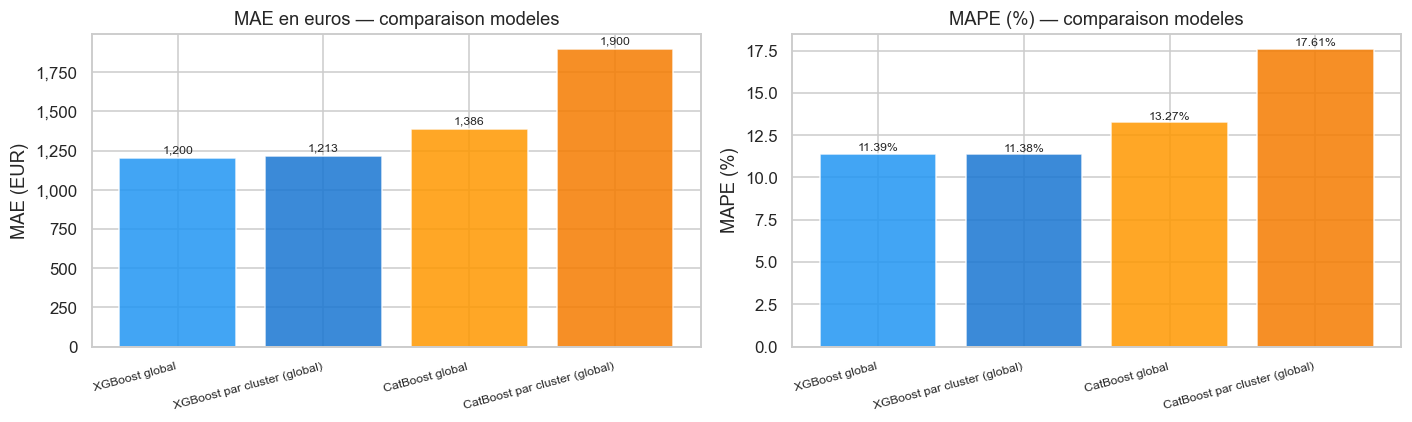

In [197]:
# ── 7.1 Tableau comparatif tous modeles ──────────────────────────────────────
res_df = pd.DataFrame(results_all).set_index('label')
display(res_df.round({'MAE_ratio':5,'R2':4,'MAE_eur':0,'RMSE_eur':0,'MAPE':2}))

# Barplot comparatif MAE en euros
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
colors_bar = ['#2196F3','#1976D2','#FF9800','#F57C00']
bars = ax.bar(res_df.index, res_df['MAE_eur'], color=colors_bar[:len(res_df)], alpha=0.85)
ax.set_title('MAE en euros — comparaison modeles')
ax.set_ylabel('MAE (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticklabels(res_df.index, rotation=15, ha='right', fontsize=8)
for bar, val in zip(bars, res_df['MAE_eur']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=8)

ax = axes[1]
bars2 = ax.bar(res_df.index, res_df['MAPE'], color=colors_bar[:len(res_df)], alpha=0.85)
ax.set_title('MAPE (%) — comparaison modeles')
ax.set_ylabel('MAPE (%)')
ax.set_xticklabels(res_df.index, rotation=15, ha='right', fontsize=8)
for bar, val in zip(bars2, res_df['MAPE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Meilleur modele : XGBoost global


modele,CatBoost global,CatBoost par cluster (global),XGBoost global,XGBoost par cluster (global)
fuel_type,,,,
DIESEL,1525.00,1893.00,1317.00,1294.00
ELECTRIC,2394.00,2527.00,2290.00,2351.00
PETROL,1128.00,1818.00,916.00,929.00
PETROL HEV,1989.00,1985.00,2036.00,1767.00
PETROL LPG,701.00,695.00,679.00,719.00
PETROL PHEV,2258.00,2497.00,2466.00,3687.00


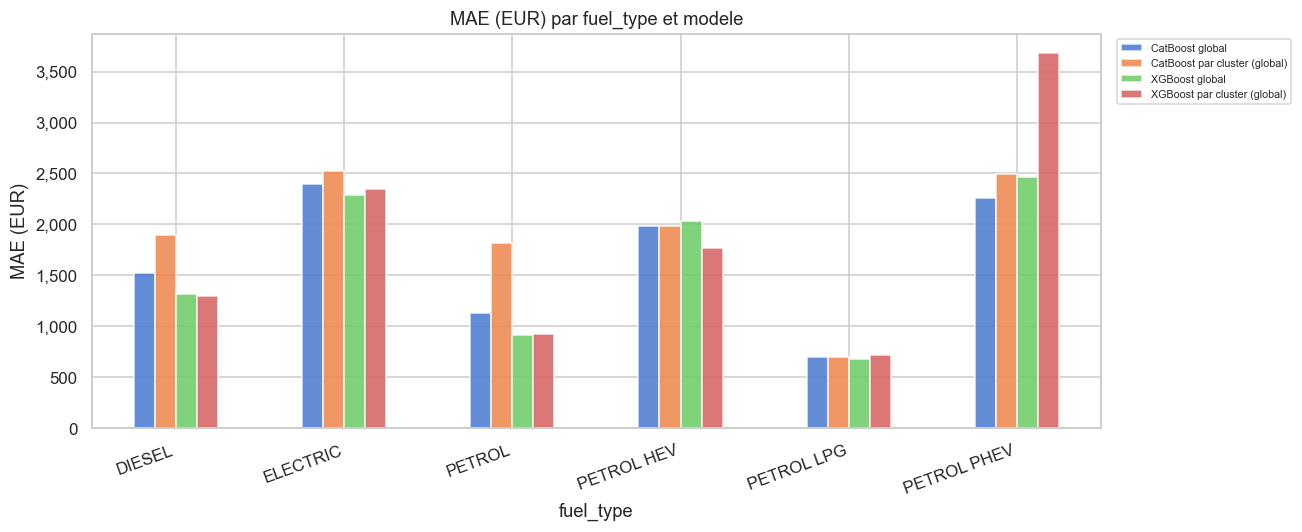

In [198]:
# ── 7.2 Performance par fuel_type — meilleur modele ──────────────────────────
# Identifier le meilleur modele (MAE_eur le plus bas)
best_label = res_df['MAE_eur'].idxmin()
print(f'Meilleur modele : {best_label}')

# Selectionner les predictions du meilleur modele
preds_map = {
    'XGBoost global'           : y_pred_xgb_global,
    'XGBoost par cluster (global)': y_pred_xgb_cl,
    'CatBoost global'          : y_pred_cb_global,
    'CatBoost par cluster (global)': y_pred_cb_cl,
}
y_pred_best = preds_map.get(best_label, y_pred_xgb_cl)

ft_test = mkt_train.loc[test_idx, 'fuel_type'].values
rows = []
for ft in sorted(set(ft_test)):
    mask = ft_test == ft
    n = mask.sum()
    if n < 10: continue
    yt = y_test[mask]; lp = lp_test[mask]
    for lbl, preds in preds_map.items():
        mae_e = mean_absolute_error(yt*lp, preds[mask]*lp)
        mape  = np.mean(np.abs((yt*lp - preds[mask]*lp)/np.clip(yt*lp,1,None)))*100
        rows.append({'fuel_type':ft, 'n':n, 'modele':lbl, 'MAE_eur':mae_e, 'MAPE':mape})

comp_ft = pd.DataFrame(rows)
pivot_mae = comp_ft.pivot(index='fuel_type', columns='modele', values='MAE_eur').round(0)
display(pivot_mae)

fig, ax = plt.subplots(figsize=(12, 5))
pivot_mae.plot(kind='bar', ax=ax, alpha=0.85, edgecolor='white')
ax.set_title('MAE (EUR) par fuel_type et modele')
ax.set_ylabel('MAE (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(fontsize=7, bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.show()

=== SHAP — Impact global des features (XGBoost) ===


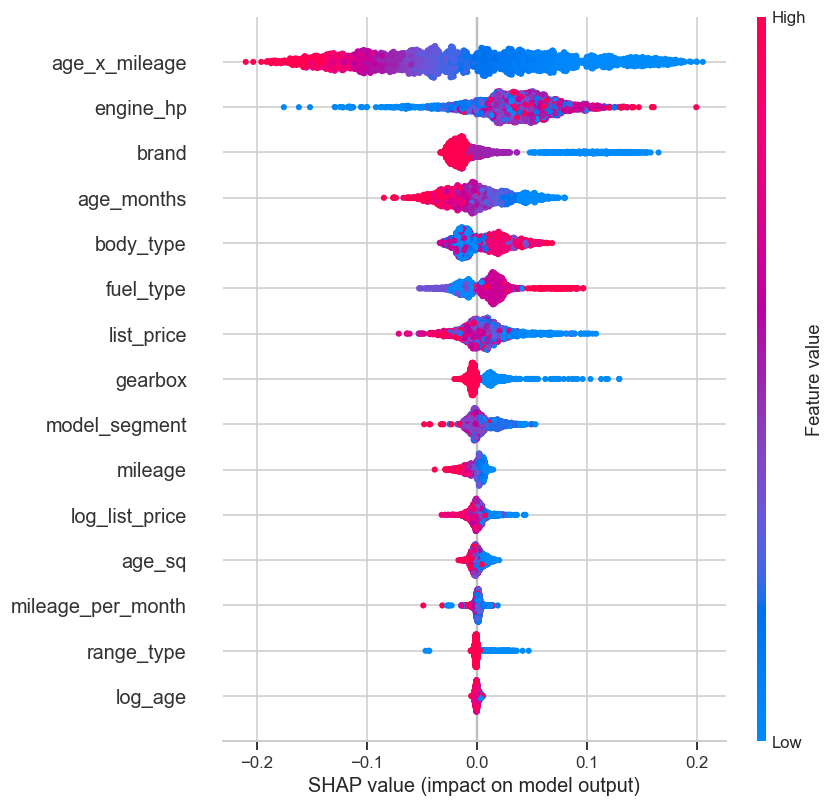

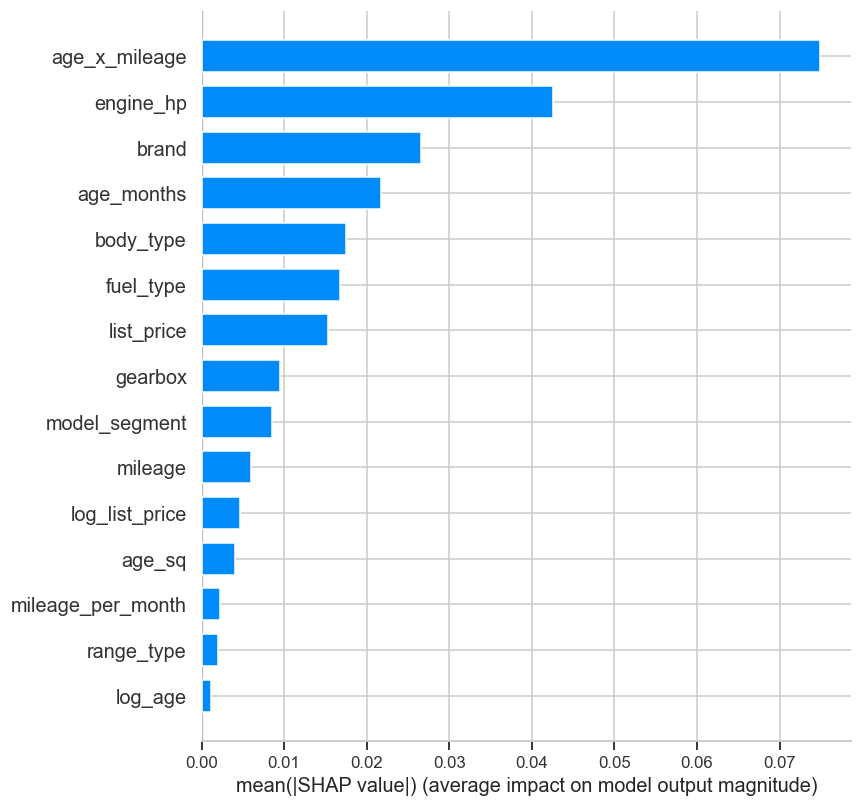

In [199]:
# ── 7.3 SHAP — meilleur modele XGBoost global ────────────────────────────────
import shap

sample_idx = np.random.default_rng(42).choice(len(X_test), size=min(3000, len(X_test)), replace=False)
X_shap = X_test.iloc[sample_idx]

explainer   = shap.TreeExplainer(xgb_global)
shap_values = explainer.shap_values(X_shap)

print('=== SHAP — Impact global des features (XGBoost) ===')
shap.summary_plot(shap_values, X_shap, plot_type='dot',
                  feature_names=list(X_train.columns), max_display=15, show=True)
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  feature_names=list(X_train.columns), max_display=15, show=True)

---
## Cellule 8 — Predictions finales sur le portfolio + Export CSV

In [200]:
# ── 8.1 Re-entrainement sur 100% des donnees (train + test) ──────────────────
print('Re-entrainement XGBoost par cluster sur 100% des donnees...')
xgb_final_cl = {}
clusters_all = mkt_train['cluster'].values

for cl in sorted(set(clusters_all)):
    mask_cl = clusters_all == cl
    if mask_cl.sum() < 100:
        continue
    best_iters = getattr(xgb_per_cluster.get(cl, xgb_global), "best_iteration", None) or 500
    m = XGBRegressor(**{**XGB_PARAMS, 'n_estimators': best_iters,
                        'early_stopping_rounds': None, 'verbosity': 0})
    m.fit(X_mkt[mask_cl], y_mkt[mask_cl])
    xgb_final_cl[cl] = m
    print(f'  Cluster {cl} : {mask_cl.sum():,} obs  |  {best_iters} arbres')

# Re-entrainement modele global (fallback pour vehicules sans cluster)
best_iters_g = getattr(xgb_global, "best_iteration", None) or 500
xgb_final_global = XGBRegressor(**{**XGB_PARAMS, 'n_estimators': best_iters_g,
                                    'early_stopping_rounds': None, 'verbosity': 0})
xgb_final_global.fit(X_mkt, y_mkt)
print(f'Modele global (fallback) : {best_iters_g} arbres')

Re-entrainement XGBoost par cluster sur 100% des donnees...
  Cluster 0 : 23,115 obs  |  45 arbres
  Cluster 1 : 145 obs  |  500 arbres
  Cluster 3 : 713,625 obs  |  1498 arbres
Modele global (fallback) : 1992 arbres


In [201]:
# ── 8.2 Predictions portfolio : VR ratio -> euros ────────────────────────────
pf_clusters = pf_enriched['cluster'].values
vr_pred      = np.zeros(len(X_pf))

for cl, m in xgb_final_cl.items():
    mask = pf_clusters == cl
    if mask.sum() == 0: continue
    vr_pred[mask] = np.clip(m.predict(X_pf[mask]), 0, 1)

# Fallback pour vehicules sans cluster
no_cluster = pf_clusters == -1
if no_cluster.sum() > 0:
    vr_pred[no_cluster] = np.clip(xgb_final_global.predict(X_pf[no_cluster]), 0, 1)
    print(f'Fallback global applique a {no_cluster.sum()} vehicules (cluster=-1)')

# Conversion en euros : VR ratio * prix catalogue
lp_pf = pf_enriched['list_price'].values
price_pred = vr_pred * lp_pf

print(f'\nPortfolio — stats des predictions :')
print(f'  VR ratio : min={vr_pred.min():.4f}  median={np.median(vr_pred):.4f}  max={vr_pred.max():.4f}')
print(f'  Prix EUR : min={price_pred.min():,.0f}  median={np.median(price_pred):,.0f}  '
      f'mean={price_pred.mean():,.0f}  max={price_pred.max():,.0f}')

# Sanity check
pf_enriched['vr_ratio_pred'] = vr_pred
pf_enriched['price_pred']    = price_pred
n_aberrant = (price_pred > lp_pf).sum()
print(f'\nSanity check :')
print(f'  Predictions > prix catalogue : {n_aberrant}  (attendu = 0 car clip a 1)')
print(f'  Predictions < 500 EUR       : {(price_pred < 500).sum()}')

print('\nVR ratio median predit par fuel_type :')
display(pf_enriched.groupby('fuel_type')[['vr_ratio_pred','price_pred']].median().round(3))

Fallback global applique a 6 vehicules (cluster=-1)

Portfolio — stats des predictions :
  VR ratio : min=0.0787  median=0.5075  max=0.7878
  Prix EUR : min=2,887  median=9,697  mean=10,538  max=32,495

Sanity check :
  Predictions > prix catalogue : 0  (attendu = 0 car clip a 1)
  Predictions < 500 EUR       : 0

VR ratio median predit par fuel_type :


,vr_ratio_pred,price_pred
fuel_type,,
DIESEL,0.42,10352.16
ELECTRIC,0.36,7527.78
PETROL,0.53,9732.19
PETROL HEV,0.56,13777.37
PETROL LPG,0.66,9055.27
PETROL PHEV,0.43,12228.45


In [ ]:
# ── 8.3 Export CSV final ─────────────────────────────────────────────────────
submission = pf_enriched[['id']].copy()
submission['prediction'] = price_pred.round(2)

submission.to_csv(OUTPUT_CSV, index=False)
print(f'Fichier exporte : {OUTPUT_CSV}')
print(f'Lignes : {len(submission):,}')
display(submission.head(10))-

Fichier exporte : predictions.csv
Lignes : 1,951


,id,prediction
0,1,10324.51
1,2,13837.34
2,3,8547.95
3,4,6500.61
4,5,7390.23
5,6,7299.26
6,7,7541.85
7,8,7867.88
8,9,8009.95
9,10,8847.71
